# Testing Model Performance
### Subliminal trials before entire epoch is run

In [1]:
from __future__ import annotations

import re
import json
import inspect
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Any
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
# ----------------------------
# Run Controls (cell is intentionally config-only)
# ----------------------------
BIRDS = ["DavidBowie", "Endive"]
SNAPSHOTS_TARGET = [100, 125, 150]
NUMFRAMES_TARGET = [200, 400, 800, 1400]

RUN_CROSS_TRIAL = True
RUN_WITHIN_TRIAL = True
SKIP_MISSING_SNAPSHOTS = True

RUN_BUILD_CLIPS = True
RUN_INFERENCE = True
RUN_EVALUATION = True

ALLOW_HIGH_LEVEL_FALLBACK = True
OVERWRITE_CLIPS = False
OVERWRITE_INFERENCE = False

VIDEO_CODEC = "MJPG"
VIDEO_FPS = 500.0

THRESHOLD_MODE = "rmse"  # rmse|fixed
FIXED_THRESHOLD_PX = 8.0

NOTEBOOK_DIR = Path.cwd()
TESTING_ROOT = NOTEBOOK_DIR.parent
DEEPLABCUT_ROOT = TESTING_ROOT / "DeepLabCut2"

print(f"Testing root: {TESTING_ROOT}")
print(f"DeepLabCut root: {DEEPLABCUT_ROOT}")

Testing root: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing
DeepLabCut root: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2


In [3]:
# ----------------------------
# Pair Mode Expansion
# ----------------------------
TRIAL_MAP = {
    "DavidBowie": [15, 17],
    "Endive": [42],
}


def build_trial_pairs(bird: str) -> list[tuple[int, int]]:
    trials = TRIAL_MAP.get(bird, [])
    pairs: list[tuple[int, int]] = []

    if RUN_CROSS_TRIAL and len(trials) >= 2:
        for t in trials:
            for e in trials:
                if t != e:
                    pairs.append((t, e))

    if RUN_WITHIN_TRIAL:
        for t in trials:
            if t == 17:
                continue
            else:
                pairs.append((t, t))

    # deterministic order + unique
    pairs = sorted(set(pairs), key=lambda x: (x[0], x[1]))
    return pairs


all_pair_rows: list[dict[str, Any]] = []
for bird in BIRDS:
    for train_trial, eval_trial in build_trial_pairs(bird):
        all_pair_rows.append(
            {
                "bird": bird,
                "train_trial": train_trial,
                "eval_trial": eval_trial,
                "pair_slug": f"TrainT{train_trial}_EvalT{eval_trial}",
            }
        )
    

pair_df = pd.DataFrame(all_pair_rows)
pair_df = pair_df[~((pair_df['train_trial'] == 17) & (pair_df['eval_trial'] == 17))]  # exclude T17-T17 due to missing snapshots
display(pair_df)

,bird,train_trial,eval_trial,pair_slug
0,DavidBowie,15,15,TrainT15_EvalT15
1,DavidBowie,15,17,TrainT15_EvalT17
2,DavidBowie,17,15,TrainT17_EvalT15
3,Endive,42,42,TrainT42_EvalT42


In [4]:

from pathlib import Path
from typing import Iterable
import re
from PIL import Image

def extract_images_by_indices(
    source_dir: str | Path,
    output_dir: str | Path,
    indices: Iterable[int],
    one_based: bool = True,
) -> dict:
    """
    Copy selected images from source_dir into output_dir as JPGs.

    Args:
        source_dir: Folder containing images.
        output_dir: Folder to create/write selected images.
        indices: Frame indices to extract.
        one_based: True if indices start at 1 (default), else 0-based.

    Returns:
        Dict with written files and skipped indices.
    """
    source_dir = Path(source_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    def sort_key(p: Path):
        m = re.search(r"(\d+)$", p.stem)
        frame_num = int(m.group(1)) if m else 10**12
        return (frame_num, p.name.lower())

    images = sorted(
        [p for p in source_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts],
        key=sort_key,
    )

    written = []
    skipped = []

    for idx in sorted(set(int(i) for i in indices)):
        i = idx - 1 if one_based else idx
        if i < 0 or i >= len(images):
            skipped.append(idx)
            continue

        src = images[i]
        dst = output_dir / f"{idx:04d}.jpg"

        with Image.open(src) as im:
            im.convert("RGB").save(dst, format="JPEG", quality=95)

        written.append(str(dst))

    return {
        "source_count": len(images),
        "requested_count": len(set(int(i) for i in indices)),
        "written_count": len(written),
        "skipped_indices": skipped,
        "written_files": written,
    }

In [ ]:
# result = extract_images_by_indices(
#     source_dir=r"C:\path\to\cam1",
#     output_dir=r"C:\path\to\selected\cam1",
#     indices=[1, 5, 12, 100],
#     one_based=True,
# )
# print(result)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\path\\to\\cam1'

In [5]:
# ----------------------------
# Shared Helpers: Naming + Discovery
# ----------------------------


def pair_slug(train_trial: int, eval_trial: int) -> str:
    return f"TrainT{train_trial}_EvalT{eval_trial}"


def bird_root(bird: str) -> Path:
    return DEEPLABCUT_ROOT / bird


def batch_root(bird: str) -> Path:
    return bird_root(bird) / "ExperimentEval" 


def model_build_root(bird: str) -> Path:
    return bird_root(bird) / "Model519"


def discover_model_configs_for_trial(bird: str, train_trial: int) -> list[Path]:
    root = model_build_root(bird)
    if not root.exists():
        return []

    configs = sorted(root.glob(f"n*_T{train_trial}/Canari-Tyler-*/config.yaml"))
    return [c for c in configs if c.exists()]


def extract_numframes_from_model_dir(model_dir_name: str) -> int | None:
    m = re.search(r"n(\d+)_T\d+$", model_dir_name)
    return int(m.group(1)) if m else None

In [6]:
# ----------------------------
# Shared Helpers: Eval Assets + Clips
# ----------------------------


def resolve_eval_train_dir(bird: str, eval_trial: int) -> Path:
    d = bird_root(bird) / "ExperimentEval" / f"TrainT{eval_trial}*"
    matches = sorted(d.parent.glob(d.name))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Could not find eval training dir for {bird} T{eval_trial}: {d}")

# FIXME: I am flawed in the search for this cam dir!!!
def resolve_cam_dir(bird: str, eval_trial: int, cam_idx: int) -> Path:
    train_dir = bird_root(bird) / f"TrainingData_T{eval_trial}"
    expected = sorted(train_dir.glob(f"Cam{cam_idx}*"))
    if expected:
        return expected[0]
    matches = sorted(train_dir.rglob(f"Cam{cam_idx}*"))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Missing Cam{cam_idx} eval image dir under {train_dir}")


def resolve_truth_csv(bird: str, eval_trial: int) -> Path:
    root = bird_root(bird) / f"TrainingData_T{eval_trial}"
    candidates = list(root.glob("*.csv"))

    if not candidates:
        raise FileNotFoundError(f"No truth CSV under {root}")
    return candidates[0]


def parse_frame_number_from_stem(stem: str) -> int | None:
    m = re.search(r"(\d+)(?!.*\d)", stem)
    return int(m.group(1)) if m else None


def collect_images(image_dir: Path) -> list[Path]:
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    images = [p for p in image_dir.iterdir() if p.is_file() and p.suffix.lower() in exts]
    return sorted(images, key=lambda p: (parse_frame_number_from_stem(p.stem) is None, parse_frame_number_from_stem(p.stem) or 0, p.name))

In [7]:
# ----------------------------
# Shared Helpers: Video Build
# ----------------------------


def build_video_from_images(
    image_paths: list[Path],
    out_video: Path,
    fps: float = VIDEO_FPS,
    codec: str = VIDEO_CODEC,
    overwrite: bool = False,
) -> dict[str, Any]:
    try:
        import cv2
    except Exception as exc:
        raise ImportError("OpenCV (cv2) is required to build evaluation clips.") from exc

    if not image_paths:
        raise ValueError(f"No image paths provided for {out_video}")

    if out_video.exists() and not overwrite:
        frame_lookup = [parse_frame_number_from_stem(p.stem) or (i + 1) for i, p in enumerate(image_paths)]
        return {"video": out_video, "status": "reused", "n_frames": len(frame_lookup), "frame_lookup": frame_lookup}

    first = cv2.imread(str(image_paths[0]))
    if first is None:
        raise FileNotFoundError(f"Could not read first image: {image_paths[0]}")

    h, w = first.shape[:2]
    out_video.parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(str(out_video), cv2.VideoWriter_fourcc(*codec), float(fps), (w, h))

    n_written = 0
    frame_lookup: list[int] = []
    for img_path in image_paths:
        frame = cv2.imread(str(img_path))
        if frame is None:
            continue
        if frame.shape[:2] != (h, w):
            frame = cv2.resize(frame, (w, h))
        writer.write(frame)
        n_written += 1
        frame_lookup.append(parse_frame_number_from_stem(img_path.stem) or n_written)

    writer.release()
    return {"video": out_video, "status": "created", "n_frames": n_written, "frame_lookup": frame_lookup}

In [8]:
# ----------------------------
# Discovery Execution: Bird/Pair/Model Inventory
# ----------------------------

inventory_rows: list[dict[str, Any]] = []

for bird in BIRDS:
    print(bird)
    for train_trial, eval_trial in build_trial_pairs(bird):
        cfgs = discover_model_configs_for_trial(bird, train_trial)
        # print(f"  Train T{train_trial} - found {len(cfgs)} model configs")
        eval_dir = resolve_eval_train_dir(bird, eval_trial)
        # print(f"  Eval T{eval_trial} - found eval dir: {eval_dir}")
        truth_csv = resolve_truth_csv(bird, eval_trial)
        # print(f"  Eval T{eval_trial} - found truth CSV: {truth_csv}")
        for cfg in cfgs:
            model_dir = cfg.parent.parent.name
            
            numframes = extract_numframes_from_model_dir(model_dir)
            # print(f"    Model {model_dir} - numframes: {numframes}")
            if numframes is None or (NUMFRAMES_TARGET and numframes not in NUMFRAMES_TARGET):
                continue

            inventory_rows.append(
                {
                    "bird": bird,
                    "train_trial": train_trial,
                    "eval_trial": eval_trial,
                    "pair_slug": pair_slug(train_trial, eval_trial),
                    "model_dir": model_dir,
                    "numframes": numframes,
                    "config_path": str(cfg),
                    "eval_dir": str(eval_dir),
                    "truth_csv": str(truth_csv),
                }
            )

inventory_df = pd.DataFrame(inventory_rows).sort_values(["bird", "train_trial", "eval_trial", "numframes"]).reset_index(drop=True)
print(f"Discovered inventory rows: {len(inventory_df)}")
display(inventory_df.head(50))

DavidBowie
Endive
Discovered inventory rows: 16


,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,config_path,eval_dir,truth_csv
0,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
1,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
2,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
3,DavidBowie,15,15,TrainT15_EvalT15,n1400_T15,1400,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
4,DavidBowie,15,17,TrainT15_EvalT17,n200_T15,200,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
5,DavidBowie,15,17,TrainT15_EvalT17,n400_T15,400,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
6,DavidBowie,15,17,TrainT15_EvalT17,n800_T15,800,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
7,DavidBowie,15,17,TrainT15_EvalT17,n1400_T15,1400,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
8,DavidBowie,17,15,TrainT17_EvalT15,n200_T17,200,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
9,DavidBowie,17,15,TrainT17_EvalT15,n400_T17,400,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...


In [9]:
for i in range(len(inventory_df)):
    print(inventory_df['truth_csv'][i])

c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T15\LabeledBodyPartsCoordinates.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T15\LabeledBodyPartsCoordinates.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T15\LabeledBodyPartsCoordinates.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T15\LabeledBodyPartsCoordinates.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T17\LabeledBodyPartsCoordinates.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T17\LabeledBodyPartsCoordinates.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\TrainingData_T17\LabeledBod

In [10]:
# ----------------------------
# Snapshot Helpers
# ----------------------------


def discover_snapshot_files(config_path: Path) -> list[Path]:
    model_root = config_path.parent
    candidates = sorted(model_root.rglob("snapshot-*.pt"))
    if candidates:
        return candidates
    # fallback pattern used in older layouts
    return sorted(model_root.rglob("*snapshot*.pt"))


def parse_snapshot_number(snapshot_path: Path) -> int | None:
    m = re.search(r"snapshot[-_](\d+)", snapshot_path.stem)
    return int(m.group(1)) if m else None


def select_snapshot_files(snapshot_files: list[Path], targets: list[int]) -> tuple[dict[int, Path], list[int]]:
    by_num: dict[int, Path] = {}
    for s in snapshot_files:
        n = parse_snapshot_number(s)
        if n is not None and n not in by_num:
            by_num[n] = s

    missing = [n for n in targets if n not in by_num]
    selected = {n: by_num[n] for n in targets if n in by_num}
    return selected, missing

In [11]:
# ----------------------------
# Snapshot Availability Table
# ----------------------------

snapshot_rows: list[dict[str, Any]] = []

for _, row in inventory_df.iterrows():
    cfg = Path(row["config_path"])
    files = discover_snapshot_files(cfg) 
    selected, missing = select_snapshot_files(files, SNAPSHOTS_TARGET)

    for n in SNAPSHOTS_TARGET:
        snapshot_rows.append(
            {
                "bird": row["bird"],
                "train_trial": int(row["train_trial"]),
                "eval_trial": int(row["eval_trial"]),
                "pair_slug": row["pair_slug"],
                "model_dir": row["model_dir"],
                "numframes": int(row["numframes"]),
                "snapshot_num": n,
                "found": n in selected,
                "snapshot_path": str(selected[n]) if n in selected else None,
                "status": "missing" if n in missing else "ready",
            }
        )

snapshot_df = pd.DataFrame(snapshot_rows).sort_values(
    ["bird", "train_trial", "eval_trial", "numframes", "snapshot_num"]
).reset_index(drop=True)

print("Snapshot availability:")
display(snapshot_df.head(100))
print(snapshot_df["status"].value_counts(dropna=False))

Snapshot availability:


,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,found,snapshot_path,status
0,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,100,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
1,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,125,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
2,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,150,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
3,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,100,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
4,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,125,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
5,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,150,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
6,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,100,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
7,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,125,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
8,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,150,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
9,DavidBowie,15,15,TrainT15_EvalT15,n1400_T15,1400,100,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready


status
ready    48
Name: count, dtype: int64


In [12]:
for i in range(4):
    snapshot_path = snapshot_df['snapshot_path'][i]
    print(f"Snapshot path for row {i}: {snapshot_path}")

Snapshot path for row 0: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T15\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt
Snapshot path for row 1: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T15\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-125.pt
Snapshot path for row 2: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T15\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-150.pt
Snapshot path for row 3: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T15\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt


In [13]:
# ----------------------------
# Backend Probe: Low-level PyTorch APIs
# ----------------------------

backend_info: dict[str, Any] = {
    "has_deeplabcut": False,
    "has_pytorch_api_module": False,
    "low_level_supported": False,
    "analyze_videos_signature": None,
}

try:
    import deeplabcut

    backend_info["has_deeplabcut"] = True

    try:
        from deeplabcut.pose_estimation_pytorch import apis as dlc_pt_apis

        backend_info["has_pytorch_api_module"] = True
        if hasattr(dlc_pt_apis, "analyze_videos"):
            backend_info["low_level_supported"] = True
            backend_info["analyze_videos_signature"] = str(inspect.signature(dlc_pt_apis.analyze_videos))
    except Exception as exc:
        backend_info["pytorch_api_error"] = str(exc)
except Exception as exc:
    backend_info["deeplabcut_import_error"] = str(exc)

print(json.dumps(backend_info, indent=2))

Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)
{
  "has_deeplabcut": true,
  "has_pytorch_api_module": true,
  "low_level_supported": true,
  "analyze_videos_signature": "(config: 'str', videos: 'str | list[str]', videotype: 'str | None' = None, shuffle: 'int' = 1, trainingsetindex: 'int' = 0, save_as_csv: 'bool' = False, in_random_order: 'bool' = False, snapshot_index: 'int | str | None' = None, detector_snapshot_index: 'int | str | None' = None, device: 'str | None' = None, destfolder: 'str | None' = None, batch_size: 'int | None' = None, detector_batch_size: 'int | None' = None, dynamic: 'tuple[bool, float, int]' = (False, 0.5, 10), ctd_conditions: 'dict | CondFromModel | None' = None, ctd_tracking: 'bool | dict | CTDTrackingConfig' = False, top_down_dynamic: 'dict | None' = None, modelprefix: 'str' = '', use_shelve: 'bool' = False, robust_nframes: 'bool' = False, transform: 'A.Compose | None' = None, auto_track: '

In [14]:
# ----------------------------
# Build Run Queue (one row = one snapshot run)
# ----------------------------

run_rows: list[dict[str, Any]] = []

for _, srow in snapshot_df.iterrows():
    if not bool(srow["found"]):
        if SKIP_MISSING_SNAPSHOTS:
            continue
        raise FileNotFoundError(
            f"Missing requested snapshot {srow['snapshot_num']} for {srow['model_dir']} ({srow['pair_slug']})."
        )

    out_dir = (
        batch_root(str(srow["bird"]))
        / str(srow["pair_slug"])
        / f"n{int(srow['numframes'])}_T{int(srow['train_trial'])}_{int(srow['snapshot_num'])}epochs"
    )

    run_rows.append(
        {
            "bird": str(srow["bird"]),
            "train_trial": int(srow["train_trial"]),
            "eval_trial": int(srow["eval_trial"]),
            "pair_slug": str(srow["pair_slug"]),
            "model_dir": str(srow["model_dir"]),
            "numframes": int(srow["numframes"]),
            "snapshot_num": int(srow["snapshot_num"]),
            "snapshot_path": str(srow["snapshot_path"]),
            "output_dir": str(out_dir),
            "status": "queued",
        }
    )

run_queue_df = pd.DataFrame(run_rows).sort_values(
    ["bird", "train_trial", "eval_trial", "numframes", "snapshot_num"]
).reset_index(drop=True)

print(f"Run queue rows: {len(run_queue_df)}")
display(run_queue_df.head(100))
# we do not wont to run train 17 eval 17 because of the bad quality of the data but we do want to run train 17 eval 15 and train 15 eval 17
run_queue_df = run_queue_df[(run_queue_df["train_trial"] != 17) | (run_queue_df["eval_trial"] != 17)]
display(run_queue_df.head(100))
print(run_queue_df['output_dir'][0])

Run queue rows: 48


,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status
0,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
1,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
2,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
3,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
4,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
5,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
6,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
7,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
8,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
9,DavidBowie,15,15,TrainT15_EvalT15,n1400_T15,1400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued


,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status
0,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
1,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
2,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
3,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
4,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
5,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
6,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
7,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
8,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
9,DavidBowie,15,15,TrainT15_EvalT15,n1400_T15,1400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued


c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\ExperimentEval\TrainT15_EvalT15\n200_T15_100epochs


In [15]:
for i in range(6):
    run_queue_path = run_queue_df['snapshot_path'][i]
    print(f"Run queue path for row {i}: {run_queue_path}")

Run queue path for row 0: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T15\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt
Run queue path for row 1: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T15\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-125.pt
Run queue path for row 2: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T15\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-150.pt
Run queue path for row 3: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T15\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt
Run 

In [17]:
# Endive: find union of frames used for training, then list frames not used.

image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

ENDIVE_ROOT = DEEPLABCUT_ROOT / "Endive"
ENDIVE_TRAINING_DIR = ENDIVE_ROOT / "TrainingData_T42" 


def extract_frame_number_from_stem(stem: str) -> int | None:
    # Example stem: Endive_20251606_F32_cam1_0521 -> frame 521
    match = re.search(r"(\d+)$", stem)
    if not match:
        return None
    return int(match.group(1))


endive_config_paths = discover_model_configs_for_trial("Endive", train_trial=42)
if not endive_config_paths:
    raise FileNotFoundError(f"No Endive model config files found under {ENDIVE_ROOT / 'TestData'}")

# Union of all frame IDs used by any Endive model.
endive_used_frames_union: set[int] = set()
per_model_frame_counts: list[dict[str, Any]] = []

for config_path in sorted(endive_config_paths):
    print(f"Processing Endive model config: {config_path}")
    labeled_dir = config_path.parent / "labeled-data"
    image_paths = [
        p for p in labeled_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in image_exts
    ]

    frame_ids = {
        frame_id
        for p in image_paths
        for frame_id in [extract_frame_number_from_stem(p.stem)]
        if frame_id is not None
    }

    endive_used_frames_union.update(frame_ids)
    per_model_frame_counts.append(
        {
            "model": config_path.parent.name,
            "n_unique_frames_used": len(frame_ids),
            "labeled_data_dir": str(labeled_dir),
        }
    )

# Determine all available frame IDs from Endive trainingdata CSV.
training_csvs = sorted(ENDIVE_TRAINING_DIR.glob("*.csv"))
if not training_csvs:
    raise FileNotFoundError(f"No CSV files found in {ENDIVE_TRAINING_DIR}")

endive_training_csv_path = training_csvs[0]
endive_training_df = pd.read_csv(endive_training_csv_path)

# CSV rows correspond to frames; use 1-based IDs to match image naming like ..._0001.
endive_all_training_frames = set(range(1, len(endive_training_df) + 1))

# Frames present in trainingdata but never used by any model's labeled-data.
endive_unused_training_frames = sorted(endive_all_training_frames - endive_used_frames_union)

# Also keep used-in-trainingdata intersection for sanity checks.
endive_used_training_frames = sorted(endive_all_training_frames & endive_used_frames_union)

print(f"Training CSV: {endive_training_csv_path}")
print(f"Total frames in trainingdata CSV: {len(endive_all_training_frames)}")
print(f"Union of used frames across Endive models: {len(endive_used_frames_union)}")
print(f"Used frames that are in trainingdata: {len(endive_used_training_frames)}")
print(f"Unused frames in trainingdata: {len(endive_unused_training_frames)}")

# Requested output list.
endive_unused_training_frames[:25], endive_unused_training_frames[-25:]

Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Endive\Model519\n1400_T42\Canari-Tyler-2026-05-22\config.yaml
Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Endive\Model519\n200_T42\Canari-Tyler-2026-05-22\config.yaml
Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Endive\Model519\n400_T42\Canari-Tyler-2026-05-22\config.yaml
Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Endive\Model519\n800_T42\Canari-Tyler-2026-05-22\config.yaml
Training CSV: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Endive\TrainingData_T42\LabeledBodyPartsCoordinates.csv
Total frames in trainingdata CSV: 3838
Union of used frames across Endive models: 1400
Used frames that are in trainingdata: 14

([2,
  3,
  4,
  5,
  7,
  9,
  11,
  12,
  14,
  15,
  17,
  23,
  25,
  26,
  27,
  30,
  32,
  33,
  34,
  38,
  39,
  40,
  42,
  48,
  51],
 [3801,
  3802,
  3803,
  3805,
  3806,
  3807,
  3809,
  3810,
  3811,
  3812,
  3813,
  3816,
  3818,
  3819,
  3820,
  3822,
  3824,
  3826,
  3827,
  3830,
  3831,
  3834,
  3835,
  3836,
  3837])

In [23]:
# ----------------------------
# Execution Helpers: Clip Prep + Inference Adapter
# ----------------------------


def get_inventory_row(bird: str, train_trial: int, eval_trial: int, numframes: int) -> pd.Series:
    """Return the single inventory row matching bird, train/eval trials, and frame count.

    Args:
        bird: Bird name (e.g., 'DavidBowie', 'Endive').
        train_trial: Training trial ID.
        eval_trial: Evaluation trial ID.
        numframes: Model frame-count setting (n).

    Returns:
        Matching inventory row as a pandas Series.

    Raises:
        KeyError: If no matching row exists.
    """
    m = inventory_df[
        (inventory_df["bird"] == bird)
        & (inventory_df["train_trial"] == train_trial)
        & (inventory_df["eval_trial"] == eval_trial)
        & (inventory_df["numframes"] == numframes)
    ]
    if m.empty:
        raise KeyError(f"Inventory row missing for {bird}, T{train_trial}->T{eval_trial}, n{numframes}")
    return m.iloc[0]


def ensure_eval_clips_for_run(bird: str, eval_trial: int, pair_slug_text: str) -> tuple[list[Path], dict[str, list[int]]]:
    """
    Ensure evaluation clips exist for a given bird/trial pair and return clip paths
    plus frame-to-source lookup metadata.

    Endive-specific logic:
    - Requires `endive_unused_training_frames` to exist in globals.
    - Builds clips from only that subset of frame IDs (not all images).
    - Uses `overwrite=True` for clip regeneration in this branch.
    - Frame lookup is exactly the selected Endive subset IDs.

    Non-Endive logic:
    - Uses all discovered images in each camera directory.
    - Respects overwrite policy via `OVERWRITE_CLIPS and RUN_BUILD_CLIPS`.
    - Frame lookup comes from `build_video_from_images(...)` output.

    Args:
        bird: Bird name key used by project path helpers (e.g., "DavidBowie", "Endive").
        eval_trial: Evaluation trial number used in file naming and directory resolution.
        pair_slug_text: Pair slug such as "TrainT15_EvalT17" used in output directory structure.

    Returns:
        A tuple:
        - subset_videos: [cam1_clip_path, cam2_clip_path]
        - frame_lookup_by_cam: {"cam1": [...], "cam2": [...]}
          Lists contain source frame IDs corresponding to clip frame order.
          If existing clips are reused, lists are empty.

    Raises:
        RuntimeError:
            If Endive subset frame list is required but missing, or no subset images are found.
        FileNotFoundError:
            If required eval directories/images cannot be resolved by helper functions.
        ValueError:
            Propagated from clip builder if no image paths are available.
        ImportError:
            Propagated from clip builder if OpenCV is unavailable.
    """
    if bird == "Endive":
        clip_dir = batch_root(bird) / pair_slug_text / "sv_new"
    else:
        clip_dir = batch_root(bird) / pair_slug_text / "sv"
    clip_dir.mkdir(parents=True, exist_ok=True)

    # deterministic clip paths
    cam1_clip = clip_dir / f"{bird.lower()}_cam1_T{eval_trial}.avi"
    cam2_clip = clip_dir / f"{bird.lower()}_cam2_T{eval_trial}.avi"

    overwrite_now = OVERWRITE_CLIPS and RUN_BUILD_CLIPS

    # Fast path: if pair eval folder already has clips, use them directly.
    # This supports existing sv/sv_new clips regardless of exact filename prefix.
    pair_dir = batch_root(bird) / pair_slug_text
    clip_search_dirs = [pair_dir / "sv", pair_dir / "sv_new"]
    for existing_dir in clip_search_dirs:
        if not existing_dir.exists():
            continue
        existing_avis = sorted(existing_dir.glob("*.avi"))
        if len(existing_avis) < 2:
            continue

        by_cam: dict[str, Path] = {}
        for p in existing_avis:
            low = p.name.lower()
            if "cam1" in low and "cam1" not in by_cam:
                by_cam["cam1"] = p
            elif "cam2" in low and "cam2" not in by_cam:
                by_cam["cam2"] = p

        if "cam1" in by_cam and "cam2" in by_cam and not overwrite_now:
            return [by_cam["cam1"], by_cam["cam2"]], {"cam1": [], "cam2": []}

    # Reuse deterministic clip paths when they already exist
    if (not overwrite_now) and cam1_clip.exists() and cam2_clip.exists():
        return [cam1_clip, cam2_clip], {"cam1": [], "cam2": []}

    eval_dir = resolve_eval_train_dir(bird, eval_trial)
    cam_dirs = [resolve_cam_dir(bird, eval_trial, 1), resolve_cam_dir(bird, eval_trial, 2)]

    subset_videos: list[Path] = []
    frame_lookup_by_cam: dict[str, list[int]] = {}

    for cam_dir in cam_dirs:
        camera = "cam2" if "cam2" in cam_dir.name.lower() else "cam1"
        all_images = collect_images(cam_dir)

        if bird == "Endive":
            if "endive_unused_training_frames" not in globals():
                raise RuntimeError("Run the Endive unused-frame cell first so endive_unused_training_frames exists.")

            # exact ordered lookup used for both clip build and eval mapping
            frame_lookup = [int(x) for x in endive_unused_training_frames]

            by_frame: dict[int, Path] = {}
            for p in all_images:
                fid = parse_frame_number_from_stem(p.stem)
                if fid is not None and fid not in by_frame:
                    by_frame[int(fid)] = p

            selected_images = [by_frame[fid] for fid in frame_lookup if fid in by_frame]
            if not selected_images:
                raise RuntimeError(f"No Endive subset images selected for {camera} in {cam_dir}")

            clip_path = cam1_clip if camera == "cam1" else cam2_clip
            info = build_video_from_images(selected_images, clip_path, overwrite=True)
            subset_videos.append(Path(info["video"]))
            frame_lookup_by_cam[camera] = frame_lookup
        else:
            clip_path = cam1_clip if camera == "cam1" else cam2_clip
            info = build_video_from_images(all_images, clip_path, overwrite=overwrite_now)
            subset_videos.append(Path(info["video"]))
            frame_lookup_by_cam[camera] = list(info["frame_lookup"])

    return subset_videos, frame_lookup_by_cam
# ...existing code...
# def ensure_eval_clips_for_run(bird: str, eval_trial: int, pair_slug_text: str) -> tuple[list[Path], dict[str, list[int]]]:
#     """Ensure cam1/cam2 evaluation clips exist for a run; reuse existing clips when possible.

#     Args:
#         bird: Bird name used to resolve dataset and batch folders.
#         eval_trial: Evaluation trial ID.
#         pair_slug_text: Pair slug like 'TrainT15_EvalT17'.

#     Returns:
#         Tuple of:
#         - list of clip paths [cam1_clip, cam2_clip]
#         - dict mapping camera -> frame lookup list (empty when clips are reused)
#     """
#     if bird == 'Endive':
#         clip_dir = batch_root(bird) / pair_slug_text / "sv_new"
#     else:
#         clip_dir = batch_root(bird) / pair_slug_text / "sv"
#     if clip_dir.exists():
#         print(clip_dir)
#         print(list(clip_dir.glob("*.avi")))
#         return list(clip_dir.glob("*.avi")), {"cam1": [], "cam2": []}

#     clip_dir.mkdir(parents=True, exist_ok=True)

#     cam1_clip = clip_dir / f"*cam1.avi"
#     cam2_clip = clip_dir / f"*cam2.avi"
#     overwrite_now = OVERWRITE_CLIPS and RUN_BUILD_CLIPS

#     # Fast path: reuse existing videos, do not require image-stack dirs
#     if bird == 'endive' and (not overwrite_now) and cam1_clip.exists() and cam2_clip.exists():
#         return [cam1_clip, cam2_clip], {"cam1": [], "cam2": []}

#     eval_dir = resolve_eval_train_dir(bird, eval_trial)
#     print(eval_dir)
#     cam_dirs = [resolve_cam_dir(eval_dir, eval_trial, 1), resolve_cam_dir(eval_dir, eval_trial, 2)]

#     subset_videos: list[Path] = []
#     frame_lookup_by_cam: dict[str, list[int]] = {}

#     for cam_dir in cam_dirs:
#         camera = "cam2" if "cam2" in cam_dir.name.lower() else "cam1"
#         images = collect_images(cam_dir)
#         clip_path = clip_dir / f"db_{camera}_T{eval_trial}.avi"
#         info = build_video_from_images(images, clip_path, overwrite=overwrite_now)
#         subset_videos.append(Path(info["video"]))
#         frame_lookup_by_cam[camera] = list(info["frame_lookup"])

#     return subset_videos, frame_lookup_by_cam

# def ensure_eval_clips_for_run(bird: str, eval_trial: int, pair_slug_text: str) -> tuple[list[Path], dict[str, list[int]]]:
#     eval_dir = resolve_eval_train_dir(bird, eval_trial)
#     cam_dirs = [resolve_cam_dir(eval_dir, eval_trial, 1), resolve_cam_dir(eval_dir, eval_trial, 2)]

#     clip_dir = batch_root(bird) / pair_slug_text / "sv"
#     clip_dir.mkdir(parents=True, exist_ok=True)

#     subset_videos: list[Path] = []
#     frame_lookup_by_cam: dict[str, list[int]] = {}

#     for cam_dir in cam_dirs:
#         camera = "cam2" if "cam2" in cam_dir.name.lower() else "cam1"
#         images = collect_images(cam_dir)
#         clip_path = clip_dir / f"db_{camera}_T{eval_trial}.avi"
#         info = build_video_from_images(images, clip_path, overwrite=OVERWRITE_CLIPS and RUN_BUILD_CLIPS)
#         subset_videos.append(Path(info["video"]))
#         frame_lookup_by_cam[camera] = list(info["frame_lookup"])

#     return subset_videos, frame_lookup_by_cam



def _run_pt_analyze_with_snapshot(
    config_path: Path,
    subset_videos: list[Path],
    output_dir: Path,
    snapshot_path: Path,
    snapshot_num: int,
) -> None:
    """Run DLC PyTorch video analysis using a specific snapshot.

    Args:
        config_path: Path to DLC config.yaml.
        subset_videos: Evaluation video paths to analyze.
        output_dir: Destination folder for DLC outputs.
        snapshot_path: Snapshot checkpoint file to use.
        snapshot_num: Snapshot number (for context/logging).

    Raises:
        TypeError: If the installed API exposes no supported snapshot selector.
        FileNotFoundError: If requested snapshot cannot be matched in snapshot_index mode.
    """
    from deeplabcut.pose_estimation_pytorch import apis as dlc_pt_apis

    sig = inspect.signature(dlc_pt_apis.analyze_videos)
    params = set(sig.parameters.keys())

    kwargs = {
        "config": str(config_path),
        "videos": [str(v) for v in subset_videos],
        "destfolder": str(output_dir),
        "videotype": ".avi",
        "save_as_csv": True,
    }

    # direct checkpoint args (newer/other builds)
    for k in ("model_file", "model_path", "checkpoint", "checkpoint_path", "snapshot_path"):
        if k in params:
            kwargs[k] = str(snapshot_path)
            dlc_pt_apis.analyze_videos(**kwargs)
            return

    if "snapshot_index" in params:
        # Build positional index from the exact train folder containing snapshot_path
        snaps = sorted(
            snapshot_path.parent.glob("snapshot-*.pt"),
            key=lambda p: (
                parse_snapshot_number(p) is None,
                parse_snapshot_number(p) if parse_snapshot_number(p) is not None else -1,
                p.name.lower(),
            ),
        )
        names = [p.name for p in snaps]
        if snapshot_path.name not in names:
            raise FileNotFoundError(
                f"Requested snapshot file not in discovered train snapshots: {snapshot_path}\nFound: {names}"
            )

        pos_idx = names.index(snapshot_path.name)  # 0-based
        print(f"[DLC] requested={snapshot_path.name} -> snapshot_index={pos_idx} (found {len(names)} snapshots)")

        kwargs["snapshot_index"] = pos_idx
        dlc_pt_apis.analyze_videos(**kwargs)
        return

    raise TypeError(f"No supported snapshot selector in analyze_videos signature: {sig}")




def run_snapshot_inference_one(run_row: pd.Series) -> dict[str, Any]:
    """Run one queued snapshot inference job and return a status dictionary.

    Args:
        run_row: One row from run_queue_df containing run metadata and paths.

    Returns:
        Dict with original row fields plus execution status and optional error info.
    """
    bird = str(run_row["bird"])
    train_trial = int(run_row["train_trial"])
    eval_trial = int(run_row["eval_trial"])
    pair = str(run_row["pair_slug"])
    numframes = int(run_row["numframes"])
    snapshot_num = int(run_row["snapshot_num"])
    snapshot_path = Path(str(run_row["snapshot_path"]))

    inv = get_inventory_row(bird, train_trial, eval_trial, numframes)
    config_path = Path(str(inv["config_path"]))
    output_dir = Path(str(run_row["output_dir"]))
    output_dir.mkdir(parents=True, exist_ok=True)

    subset_videos, _ = ensure_eval_clips_for_run(bird, eval_trial, pair)

    if not RUN_INFERENCE:
        return {**run_row.to_dict(), "status": "skipped_inference_disabled", "error": None}

    existing_csv = list(output_dir.glob("*DLC*.csv"))
    if existing_csv and not OVERWRITE_INFERENCE:
        return {**run_row.to_dict(), "status": "skipped_exists", "error": None}

    try:
        _run_pt_analyze_with_snapshot(
            config_path=config_path,
            subset_videos=subset_videos,
            output_dir=output_dir,
            snapshot_path=snapshot_path,
            snapshot_num=snapshot_num,
        )

        n_csv = len(list(output_dir.glob("*DLC*.csv")))
        if n_csv == 0:
            raise RuntimeError(f"No CSV output produced for snapshot {snapshot_num}")

        return {
            **run_row.to_dict(),
            "status": "done",
            "backend": "low_level_pytorch",
            "config_path": str(config_path),
            "n_csv": n_csv,
            "error": None,
        }
    except Exception as exc:
        return {**run_row.to_dict(), "status": "failed", "error": str(exc)}



In [19]:
davidbowie_run_queue_df = run_queue_df[run_queue_df['bird'] == 'DavidBowie'].reset_index(drop=True)
davidbowie_run_queue_df

,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status
0,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
1,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
2,DavidBowie,15,15,TrainT15_EvalT15,n200_T15,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
3,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
4,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
5,DavidBowie,15,15,TrainT15_EvalT15,n400_T15,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
6,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
7,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
8,DavidBowie,15,15,TrainT15_EvalT15,n800_T15,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
9,DavidBowie,15,15,TrainT15_EvalT15,n1400_T15,1400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued


In [20]:
davidbowie_run_queue_df['snapshot_path'][0]

'c:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\DavidBowie\\Model519\\n200_T15\\Canari-Tyler-2026-05-22\\dlc-models-pytorch\\iteration-0\\CanariMay22-trainset95shuffle1\\train\\snapshot-100.pt'

In [45]:
from deeplabcut.pose_estimation_pytorch import apis as dlc_pt_apis
# ----------------------------
# Execution: Run Queue David Bowie Only
# ----------------------------
OVERWRITE_INFERENCE = False
run_results: list[dict[str, Any]] = []

for _, qrow in davidbowie_run_queue_df.iterrows():
    print(f"Running inference for {qrow['pair_slug']} snapshot {qrow['snapshot_num']}... ")
    print(qrow['snapshot_path'])
    result = run_snapshot_inference_one(qrow)
    run_results.append(result)

run_results_df = pd.DataFrame(run_results)
print("Run results status:")
print(run_results_df["status"].value_counts(dropna=False))
display(run_results_df.head(100))
run_results_df["status"] = 'done'

Running inference for TrainT15_EvalT15 snapshot 100... 
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n200_T15\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt


FileNotFoundError: Missing Cam1 eval image dir under c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\ExperimentEval\TrainT15_EvalT15

In [169]:
endive_run_queue_df = run_queue_df[run_queue_df["bird"] == "Endive"].copy()
endive_run_queue_df = endive_run_queue_df.reset_index(drop=True)
endive_run_queue_df

,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status
0,Endive,32,32,TrainT32_EvalT32,Endive_n200_T32,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
1,Endive,32,32,TrainT32_EvalT32,Endive_n200_T32,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
2,Endive,32,32,TrainT32_EvalT32,Endive_n200_T32,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
3,Endive,32,32,TrainT32_EvalT32,Endive_n400_T32,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
4,Endive,32,32,TrainT32_EvalT32,Endive_n400_T32,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
5,Endive,32,32,TrainT32_EvalT32,Endive_n400_T32,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
6,Endive,32,32,TrainT32_EvalT32,Endive_n800_T32,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
7,Endive,32,32,TrainT32_EvalT32,Endive_n800_T32,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
8,Endive,32,32,TrainT32_EvalT32,Endive_n800_T32,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
9,Endive,32,32,TrainT32_EvalT32,Endive_n1400_T32,1400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued


In [ ]:
# ----------------------------
# Execution: Run Queue: Endive Only
# ----------------------------

OVERWRITE_INFERENCE = True
OVERWRITE_CLIPS = True
run_results: list[dict[str, Any]] = []

for _, qrow in endive_run_queue_df.iterrows():
    result = run_snapshot_inference_one(qrow)
    run_results.append(result)

run_results_df = pd.DataFrame(run_results)
print("Run results status:")
print(run_results_df["status"].value_counts(dropna=False))
display(run_results_df.head(100))

In [178]:
OVERWRITE_CLIPS = False
OVERWRITE_INFERENCE = False 

In [ ]:
# ----------------------------
# Execution: Run Queue: All 
# ----------------------------
# About 2 hrs to run in full
run_results: list[dict[str, Any]] = []

for _, qrow in run_queue_df.iterrows():
    result = run_snapshot_inference_one(qrow)
    run_results.append(result)

run_results_df = pd.DataFrame(run_results)
print("Run results status:")
print(run_results_df["status"].value_counts(dropna=False))
display(run_results_df.head(100))

In [38]:
import xrommtools_copy as xtc

In [53]:
# Convert all predictions into XMLAB Format
for qrow in run_queue_df.itertuples():
    bird = qrow.bird
    eval_trial = qrow.eval_trial
    pair_slug_text = qrow.pair_slug
    output_dir = Path(qrow.output_dir)
    snapshot_num = qrow.snapshot_num
    frames = qrow.numframes

    csv_files = list(output_dir.glob("*DLC*.csv"))
    print(type(str(csv_files[0])))
    if not csv_files:
        print(f"No DLC CSV found in {output_dir} for {pair_slug_text}")
        continue
    print(f"{pair_slug_text}_n{frames}_s{snapshot_num}_xmlab.csv")
    trial_name = f"{pair_slug_text}_n{frames}_s{snapshot_num}"
    xmlab_path = output_dir / "XMALAB"
    xmlab_path.mkdir(parents = True, exist_ok = True)
    cam1path = str(csv_files[0])
    cam2path = str(csv_files[1]) if len(csv_files) > 1 else None
    print(f"Converting {cam1path} and {cam2path} to XMLAB format at {xmlab_path}...")
    xtc.dlc_to_xma(cam1data = cam1path,
                               cam2data = cam2path,
                               trialname = trial_name,
                               savepath = str(xmlab_path))


    

<class 'str'>
TrainT15_EvalT15_n200_s100_xmlab.csv
Converting c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\ExperimentEval\TrainT15_EvalT15\n200_T15_100epochs\uf_cam1DLC_Resnet50_CanariMay22shuffle1_snapshot_100.csv and c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\ExperimentEval\TrainT15_EvalT15\n200_T15_100epochs\uf_cam2DLC_Resnet50_CanariMay22shuffle1_snapshot_100.csv to XMLAB format at c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\ExperimentEval\TrainT15_EvalT15\n200_T15_100epochs\XMALAB...
<class 'str'>
TrainT15_EvalT15_n200_s125_xmlab.csv
Converting c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\ExperimentEval\TrainT15_EvalT15\n200_T15_125epochs\uf_cam1DLC_Resnet50_CanariMay22shuffle1_snapshot_125.csv and c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\De

In [25]:
# ----------------------------
# Evaluation Helpers: Truth + Prediction Parsing
# ----------------------------


def infer_camera_from_name(name: str) -> str:
    low = name.lower()
    if "cam2" in low:
        return "cam2"
    return "cam1"


def truth_csv_to_long(truth_csv_path: Path) -> pd.DataFrame:
    truth_df = pd.read_csv(truth_csv_path)
    rows = []
    for col in truth_df.columns:
        m = re.match(r"(?P<bodypart>.+)_cam(?P<cam>[12])_(?P<coord>[XY])$", col)
        if m is None:
            continue
        rows.append((m.group("bodypart"), f"cam{m.group('cam')}", m.group("coord").lower(), col))

    if not rows:
        raise ValueError(f"Could not parse truth columns in {truth_csv_path}")

    meta = pd.DataFrame(rows, columns=["bodypart", "camera", "coord", "column"])
    xmeta = meta[meta["coord"] == "x"].rename(columns={"column": "xcol"})
    ymeta = meta[meta["coord"] == "y"].rename(columns={"column": "ycol"})
    pairs = xmeta.merge(ymeta[["bodypart", "camera", "ycol"]], on=["bodypart", "camera"], how="inner")

    frame_ids = np.arange(1, len(truth_df) + 1)
    parts = []
    for _, r in pairs.iterrows():
        parts.append(
            pd.DataFrame(
                {
                    "frame_id": frame_ids,
                    "bodypart": r["bodypart"],
                    "camera": r["camera"],
                    "x_true": pd.to_numeric(truth_df[r["xcol"]], errors="coerce"),
                    "y_true": pd.to_numeric(truth_df[r["ycol"]], errors="coerce"),
                }
            )
        )
    return pd.concat(parts, ignore_index=True)


def prediction_csv_to_long(pred_csv_path: Path, frame_lookup: list[int]) -> pd.DataFrame:
    wide = pd.read_csv(pred_csv_path, header=[0, 1, 2], index_col=0)
    camera = infer_camera_from_name(pred_csv_path.name)

    bodyparts = pd.Index(wide.columns.get_level_values(1)).unique()
    out = []
    for bp in bodyparts:
        bp_cols = wide.xs(bp, axis=1, level=1, drop_level=False)
        coords = bp_cols.columns.get_level_values(2).astype(str).str.lower().tolist()
        if "x" not in coords or "y" not in coords:
            continue

        xcol = bp_cols.columns[coords.index("x")]
        ycol = bp_cols.columns[coords.index("y")]
        if "likelihood" in coords:
            lcol = bp_cols.columns[coords.index("likelihood")]
            like = pd.to_numeric(bp_cols[lcol], errors="coerce").to_numpy(dtype=float)
        else:
            like = np.full(bp_cols.shape[0], np.nan)

        subset_idx = pd.to_numeric(pd.Index(wide.index), errors="coerce").astype("Int64")
        frame_ids = [frame_lookup[int(i)] if pd.notna(i) and 0 <= int(i) < len(frame_lookup) else np.nan for i in subset_idx]

        out.append(
            pd.DataFrame(
                {
                    "frame_id": frame_ids,
                    "bodypart": str(bp),
                    "camera": camera,
                    "x_pred": pd.to_numeric(bp_cols[xcol], errors="coerce").to_numpy(dtype=float),
                    "y_pred": pd.to_numeric(bp_cols[ycol], errors="coerce").to_numpy(dtype=float),
                    "likelihood": like,
                }
            )
        )

    if not out:
        raise ValueError(f"No usable prediction columns in {pred_csv_path}")
    return pd.concat(out, ignore_index=True)

# Key Frame for GUI interface with the predicted points.

In [71]:
# KEY FRAME GUI (XMALab format-aware)
import ipywidgets as widgets
from IPython.display import display

def _xmalab_wide_to_long(df: pd.DataFrame, value_prefix: str) -> pd.DataFrame:
    """Convert a wide XMALab table to long format used by the overlay viewer.

    Expected source columns:
        <bodypart>_cam1_X, <bodypart>_cam1_Y, <bodypart>_cam2_X, <bodypart>_cam2_Y
        (same pattern for every bodypart)

    Args:
        df: Wide table where each row is one frame/row position.
        value_prefix: Prefix used in output value columns, e.g. 'pred' or 'true'.

    Returns:
        Long DataFrame with columns:
            row_pos, bodypart, camera, x_<value_prefix>, y_<value_prefix>

    Raises:
        ValueError: If no XMALab-style columns are detected.
    """
    rows = []
    for col in df.columns:
        m = re.match(r"(?P<bodypart>.+)_cam(?P<cam>[12])_(?P<coord>[XY])$", str(col))
        if m is None:
            continue
        rows.append((m.group("bodypart"), f"cam{m.group('cam')}", m.group("coord").lower(), col))

    if not rows:
        raise ValueError("Could not parse XMALab columns (expected '*_cam[12]_[XY]').")

    meta = pd.DataFrame(rows, columns=["bodypart", "camera", "coord", "column"])
    xmeta = meta[meta["coord"] == "x"].rename(columns={"column": "xcol"})
    ymeta = meta[meta["coord"] == "y"].rename(columns={"column": "ycol"})
    pairs = xmeta.merge(ymeta[["bodypart", "camera", "ycol"]], on=["bodypart", "camera"], how="inner")

    row_pos = np.arange(len(df), dtype=int)
    parts = []
    for _, r in pairs.iterrows():
        parts.append(
            pd.DataFrame(
                {
                    "row_pos": row_pos,
                    "bodypart": r["bodypart"],
                    "camera": r["camera"],
                    f"x_{value_prefix}": pd.to_numeric(df[r["xcol"]], errors="coerce"),
                    f"y_{value_prefix}": pd.to_numeric(df[r["ycol"]], errors="coerce"),
                }
            )
        )

    if not parts:
        return pd.DataFrame(columns=["row_pos", "bodypart", "camera", f"x_{value_prefix}", f"y_{value_prefix}"])
    return pd.concat(parts, ignore_index=True)


def make_pred_true_overlay_widget(
    run_row: pd.Series,
    default_camera: str = "cam1",
    default_frame_pos: int = 0,
):
    """Render an interactive image overlay of predicted vs true keypoints.

    This widget is designed for XMALab-formatted predictions generated by the
    conversion step in this notebook (output_dir/XMALAB/*-Predicted2DPoints.csv).

    Alignment model:
    1) Select image by camera + frame_pos (index in that camera image list).
    2) Map that frame_pos to prediction and truth row positions independently
       using the same mapping function (`_map_row`).
    3) Apply per-stream offsets (`Pred offset`, `Truth offset`) in mapped row space.

    Mapping behavior (`_map_row`):
    - If image count == target row count: direct mapping.
    - If counts differ and 'Allow mismatch mapping' is enabled: scaled mapping.
    - If counts differ and mismatch mapping is disabled: mapping is blocked.

    Args:
        run_row: Row from run_queue_df or run_results_df.
        default_camera: Initial camera tab ('cam1' or 'cam2').
        default_frame_pos: Initial image index inside chosen camera list.

    Notes:
        - Eval trial drives truth/image source resolution:
          Eval 15 -> TrainingData_T15, Eval 17 -> TrainingData_T17.
        - Use the title diagnostics (pred_row/truth_row + map modes) to tune offsets.
    """
    bird = str(run_row["bird"])
    train_trial = int(run_row["train_trial"])
    eval_trial = int(run_row["eval_trial"])
    numframes = int(run_row["numframes"])
    out_dir = Path(str(run_row["output_dir"]))

    # 1) Load truth rows from the eval-trial training-data CSV.
    inv = get_inventory_row(bird, train_trial, eval_trial, numframes)
    truth_csv = Path(str(inv["truth_csv"]))
    truth_wide = pd.read_csv(truth_csv)
    truth_long = _xmalab_wide_to_long(truth_wide, "true")

    # 2) Load prediction rows from XMALAB conversion output for this run.
    xmalab_dir = out_dir / "XMALAB"
    pred_xma_csvs = sorted(xmalab_dir.glob("*-Predicted2DPoints.csv"))
    if not pred_xma_csvs:
        raise FileNotFoundError(f"No XMALAB prediction CSV found in {xmalab_dir}")
    pred_xma_csv = pred_xma_csvs[0]
    pred_wide = pd.read_csv(pred_xma_csv)
    pred_long = _xmalab_wide_to_long(pred_wide, "pred")

    # 3) Load eval-trial camera image stacks used as overlay background.
    cam1_dir = resolve_cam_dir(bird, eval_trial, 1)
    cam2_dir = resolve_cam_dir(bird, eval_trial, 2)
    images_by_cam = {"cam1": collect_images(cam1_dir), "cam2": collect_images(cam2_dir)}

    # 4) Cache alignment metadata for diagnostics and mapping decisions.
    n_pred_rows = int(pred_wide.shape[0])
    n_truth_rows = int(truth_wide.shape[0])
    alignment_by_cam = {}
    for cam in ("cam1", "cam2"):
        n_images = len(images_by_cam.get(cam, []))
        alignment_by_cam[cam] = {
            "n_images": n_images,
            "n_pred_rows": n_pred_rows,
            "n_truth_rows": n_truth_rows,
            "pred_direct_ok": (n_images == n_pred_rows),
            "truth_direct_ok": (n_images == n_truth_rows),
        }

    print(f"Eval trial = T{eval_trial} | truth_csv = {truth_csv.name}")
    print(f"Using XMALAB prediction file: {pred_xma_csv.name}")
    print("Prediction/Truth/Image alignment report:")
    for cam in ("cam1", "cam2"):
        a = alignment_by_cam[cam]
        print(
            f"  {cam}: images={a['n_images']} | pred_rows={a['n_pred_rows']} | truth_rows={a['n_truth_rows']} | "
            f"pred_direct_ok={a['pred_direct_ok']} | truth_direct_ok={a['truth_direct_ok']}"
        )

    def _extract_pred_points(camera: str, row_pos: int) -> pd.DataFrame:
        """Return predicted (x, y) points for one camera and mapped row position."""
        d = pred_long[
            (pred_long["camera"] == camera) & (pred_long["row_pos"] == int(row_pos))
        ][["bodypart", "x_pred", "y_pred"]].copy()
        if d.empty:
            return pd.DataFrame(columns=["bodypart", "x", "y"])
        d = d.rename(columns={"x_pred": "x", "y_pred": "y"})
        return d.dropna(subset=["x", "y"])

    def _extract_true_points(camera: str, row_pos: int) -> pd.DataFrame:
        """Return truth (x, y) points for one camera and mapped row position."""
        d = truth_long[
            (truth_long["camera"] == camera) & (truth_long["row_pos"] == int(row_pos))
        ][["bodypart", "x_true", "y_true"]].copy()
        if d.empty:
            return pd.DataFrame(columns=["bodypart", "x", "y"])
        d = d.rename(columns={"x_true": "x", "y_true": "y"})
        return d.dropna(subset=["x", "y"])

    def _map_row(frame_pos: int, n_images: int, n_target: int, offset: int, allow_mismatch: bool):
        """Map image index -> target row index for truth/prediction tables.

        Returns:
            (mapped_row_or_None, mode_string) where mode_string explains how mapping was chosen.
        """
        if n_target <= 0:
            return None, "no_target_rows"
        if n_images <= 0:
            return None, "no_images"
        if n_images == n_target:
            p = int(frame_pos + offset)
            if p < 0 or p >= n_target:
                return None, "out_of_bounds"
            return p, "direct"

        if not allow_mismatch:
            return None, "mismatch_blocked"

        if n_images == 1:
            p = int(offset)
            if p < 0 or p >= n_target:
                return None, "out_of_bounds"
            return p, "auto_single"

        # Scaled mapping preserves relative temporal position across unequal lengths.
        scaled = int(round((float(frame_pos) / float(n_images - 1)) * float(n_target - 1)))
        p = int(scaled + int(offset))
        if p < 0 or p >= n_target:
            return None, "out_of_bounds"
        return p, "auto_scaled"

    def _draw(camera, frame_pos, show_pred, show_true, annotate, truth_offset, pred_offset, allow_mismatch):
        """Main render callback called by widget controls."""
        camera = str(camera).lower().strip()
        imgs = images_by_cam.get(camera, [])
        if not imgs:
            print(f"No images for {camera}")
            return
        if frame_pos < 0 or frame_pos >= len(imgs):
            print(f"frame_pos out of range for {camera}: 0..{len(imgs)-1}")
            return

        image_path = imgs[frame_pos]
        frame_id_img = parse_frame_number_from_stem(image_path.stem) or (frame_pos + 1)

        with Image.open(image_path) as im:
            img = np.asarray(im.convert("RGB"))

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.imshow(img)

        align = alignment_by_cam.get(camera, {})

        pred_row_pos, pred_map_mode = _map_row(
            frame_pos=int(frame_pos),
            n_images=int(align.get("n_images", 0)),
            n_target=int(align.get("n_pred_rows", 0)),
            offset=int(pred_offset),
            allow_mismatch=bool(allow_mismatch),
        )

        truth_row_pos, truth_map_mode = _map_row(
            frame_pos=int(frame_pos),
            n_images=int(align.get("n_images", 0)),
            n_target=int(align.get("n_truth_rows", 0)),
            offset=int(truth_offset),
            allow_mismatch=bool(allow_mismatch),
        )

        if show_pred:
            if pred_row_pos is None:
                print(
                    f"Pred mapping unavailable for {camera} ({pred_map_mode}). "
                    f"Enable 'Allow mismatch mapping' or adjust Pred offset."
                )
            else:
                pred_pts = _extract_pred_points(camera, pred_row_pos)
                if not pred_pts.empty:
                    ax.scatter(
                        pred_pts["x"], pred_pts["y"],
                        c="deepskyblue", s=60, alpha=0.9, edgecolors="white", linewidths=1.0,
                        label="Predicted"
                    )
                    if annotate:
                        for _, rr in pred_pts.iterrows():
                            ax.text(rr["x"] + 4, rr["y"] + 4, str(rr["bodypart"]), fontsize=8, color="deepskyblue")

        if show_true:
            if truth_row_pos is None:
                print(
                    f"Truth mapping unavailable for {camera} ({truth_map_mode}). "
                    f"Enable 'Allow mismatch mapping' or adjust Truth offset."
                )
            else:
                true_pts = _extract_true_points(camera, truth_row_pos)
                if not true_pts.empty:
                    ax.scatter(
                        true_pts["x"], true_pts["y"],
                        c="orange", s=45, alpha=0.9, marker="x", linewidths=1.8,
                        label="True"
                    )
                    if annotate:
                        for _, rr in true_pts.iterrows():
                            ax.text(rr["x"] + 4, rr["y"] + 4, str(rr["bodypart"]), fontsize=8, color="orange")

        # Title intentionally exposes mapping internals for rapid debugging/tuning.
        ax.set_title(
            f"{bird} {camera} | T{train_trial}->T{eval_trial} | frame_pos={frame_pos} | pred_row={pred_row_pos} | truth_row={truth_row_pos}\n"
            f"image_frame_id={frame_id_img} | pred_map={pred_map_mode} | truth_map={truth_map_mode}"
        )
        ax.set_axis_off()
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

    # UI controls:
    # - frame_pos selects displayed image index
    # - Pred/Truth offset shift mapped rows after mapping mode is chosen
    # - Allow mismatch mapping toggles scaled mapping for unequal sequence lengths
    cam_w = widgets.ToggleButtons(options=["cam1", "cam2"], value=default_camera, description="Camera")
    max_len = max(1, len(images_by_cam.get(default_camera, []))) - 1
    frame_w = widgets.IntSlider(value=min(default_frame_pos, max_len), min=0, max=max_len, step=1, description="frame_pos")
    pred_w = widgets.Checkbox(value=True, description="Show predicted")
    true_w = widgets.Checkbox(value=True, description="Show true")
    ann_w = widgets.Checkbox(value=False, description="Annotate")
    truth_off_w = widgets.IntSlider(value=0, min=-5000, max=5000, step=1, description="Truth offset")
    pred_off_w = widgets.IntSlider(value=0, min=-5000, max=5000, step=1, description="Pred offset")
    allow_mismatch_w = widgets.Checkbox(value=True, description="Allow mismatch mapping")

    def _on_camera_change(change):
        """Keep frame slider bounds synchronized with selected camera image count."""
        if change["name"] == "value":
            c = change["new"]
            n = max(1, len(images_by_cam.get(c, []))) - 1
            frame_w.max = n
            if frame_w.value > n:
                frame_w.value = n

    cam_w.observe(_on_camera_change)

    ui = widgets.VBox([
        widgets.HBox([cam_w, frame_w]),
        widgets.HBox([pred_w, true_w, ann_w]),
        widgets.HBox([truth_off_w, pred_off_w]),
        widgets.HBox([allow_mismatch_w]),
    ])

    out = widgets.interactive_output(
        _draw,
        {
            "camera": cam_w,
            "frame_pos": frame_w,
            "show_pred": pred_w,
            "show_true": true_w,
            "annotate": ann_w,
            "truth_offset": truth_off_w,
            "pred_offset": pred_off_w,
            "allow_mismatch": allow_mismatch_w,
        },
    )
    display(ui, out)

In [70]:
# Pick an eval trial explicitly so truth/images match the desired training-data folder.
# Eval 15 -> TrainingData_T15, Eval 17 -> TrainingData_T17
TARGET_EVAL_TRIAL = 17  # change to 17 to inspect EvalT17

sel = run_queue_df[run_queue_df["eval_trial"] == TARGET_EVAL_TRIAL].copy()
if sel.empty:
    raise ValueError(f"No run rows found for eval_trial={TARGET_EVAL_TRIAL}")

# Optional: choose a specific snapshot if desired.
# sel = sel[sel["snapshot_num"] == 150]

r = sel.iloc[0]
print(f"Using row: bird={r['bird']} train={r['train_trial']} eval={r['eval_trial']} n={r['numframes']} s={r['snapshot_num']}")
make_pred_true_overlay_widget(r, default_camera="cam1", default_frame_pos=0)

Using row: bird=DavidBowie train=15 eval=17 n=200 s=100
Eval trial = T17 | truth_csv = LabeledBodyPartsCoordinates.csv
Using XMALAB prediction file: TrainT15_EvalT17_n200_s100-Predicted2DPoints.csv
Prediction/Truth/Image alignment report:
  cam1: images=1560 | pred_rows=1560 | truth_rows=1560 | pred_direct_ok=True | truth_direct_ok=True
  cam2: images=1560 | pred_rows=1560 | truth_rows=1560 | pred_direct_ok=True | truth_direct_ok=True


Output()

In [74]:
# ----------------------------
# Evaluation Execution (Direct XMALab Row Comparison)
# ----------------------------

summary_rows: list[dict[str, Any]] = []
error_rows_all: list[pd.DataFrame] = []


def _resolve_unused_frames_csv(bird: str, train_trial: int, eval_trial: int) -> Path | None:
    """Return unused-frames CSV path for within-trial subset eval runs, else None."""
    if train_trial != eval_trial:
        return None

    pair_dir = bird_root(bird) / "ExperimentEval" / f"TrainT{train_trial}_EvalT{eval_trial}"
    candidates = sorted(pair_dir.glob("*unused*training*frames*.csv")) + sorted(pair_dir.glob("*unused*frames*.csv"))
    if candidates:
        return candidates[0]

    # Fallbacks requested by user; used if pair folder naming varies.
    if bird == "DavidBowie" and train_trial == 15 and eval_trial == 15:
        p = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\ExperimentEval\TrainT15_EvalT15\david_bowie_unused_training_frames.csv")
        return p if p.exists() else None

    if bird == "Endive" and train_trial == 42 and eval_trial == 42:
        p = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Endive\ExperimentEval\TrainT42_EvalT42\end_unused_training_frames.csv")
        return p if p.exists() else None

    return None


def _extract_frame_ids_from_csv(path: Path) -> list[int]:
    """Load frame ids (1-based) from an unused-frames CSV using common column names."""
    df = pd.read_csv(path)
    for col in ("frame_id", "frame", "frame_num", "frame_number", "Frame", "FrameID", "FrameNum"):
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors="coerce").dropna().astype(int).tolist()
            return [v for v in vals if v > 0]

    # If no named frame column exists, use first numeric-like column.
    for col in df.columns:
        vals = pd.to_numeric(df[col], errors="coerce")
        if vals.notna().any():
            ints = vals.dropna().astype(int).tolist()
            return [v for v in ints if v > 0]

    raise ValueError(f"No usable frame-id column found in {path}")


if RUN_EVALUATION:
    for _, r in run_results_df.iterrows():
        if str(r.get("status", "")) not in ("done", "skipped_exists"):
            continue

        try:
            bird = str(r["bird"])
            train_trial = int(r["train_trial"])
            eval_trial = int(r["eval_trial"])
            numframes = int(r["numframes"])
            snapshot_num = int(r["snapshot_num"])
            pair = str(r["pair_slug"])
            out_dir = Path(str(r["output_dir"]))

            print(f"Evaluating {bird} T{train_trial}->T{eval_trial}, n{numframes}, snapshot {snapshot_num}")

            # Truth: eval-trial training-data CSV (XMALab-style wide columns).
            inv = get_inventory_row(bird, train_trial, eval_trial, numframes)
            truth_csv = Path(str(inv["truth_csv"]))
            truth_wide = pd.read_csv(truth_csv)

            # For within-trial subset runs, align truth to the exact unused frame list order.
            unused_csv = _resolve_unused_frames_csv(bird, train_trial, eval_trial)
            truth_mode = "full_truth"
            if unused_csv is not None:
                frame_ids = _extract_frame_ids_from_csv(unused_csv)
                zero_idx = [fid - 1 for fid in frame_ids if 0 < fid <= len(truth_wide)]
                if not zero_idx:
                    raise ValueError(f"Unused-frame CSV found but no valid indices in range: {unused_csv}")
                truth_wide = truth_wide.iloc[zero_idx].reset_index(drop=True)
                truth_mode = "unused_training_subset"
                print(f"Using subset truth from {unused_csv.name}: {len(zero_idx)} rows")

            truth_long = _xmalab_wide_to_long(truth_wide, "true")

            # Predictions: converted XMALab CSV produced in conversion step.
            xmalab_dir = out_dir / "XMALAB"
            pred_xma_csvs = sorted(xmalab_dir.glob("*-Predicted2DPoints.csv"))
            if not pred_xma_csvs:
                print(f"No XMALAB prediction CSV in {xmalab_dir}; skipping.")
                continue

            pred_xma_csv = pred_xma_csvs[0]
            pred_wide = pd.read_csv(pred_xma_csv)
            pred_long = _xmalab_wide_to_long(pred_wide, "pred")

            # Direct comparison: join on row_pos/bodypart/camera in the same schema.
            merged = pred_long.merge(truth_long, on=["row_pos", "bodypart", "camera"], how="inner")
            merged = merged.dropna(subset=["row_pos", "x_pred", "y_pred", "x_true", "y_true"]).copy()

            print(
                f"Row overlap: pred_rows={len(pred_wide)} truth_rows={len(truth_wide)} merged_points={len(merged)}"
            )

            if merged.empty:
                print("Merged table is empty; skipping metrics for this run.")
                continue

            merged["distance_px"] = np.sqrt(
                (merged["x_pred"] - merged["x_true"]) ** 2 + (merged["y_pred"] - merged["y_true"]) ** 2
            )
            rmse = float(np.sqrt(np.mean(np.square(merged["distance_px"]))))
            threshold_px = rmse if THRESHOLD_MODE == "rmse" else float(FIXED_THRESHOLD_PX)
            merged["within_threshold"] = merged["distance_px"] <= threshold_px

            pct_points = 100.0 * float(merged["within_threshold"].mean())
            expected_per_row = pred_long[["camera", "bodypart"]].drop_duplicates().shape[0]
            row_stats = merged.groupby("row_pos", as_index=False).agg(
                n_points=("within_threshold", "size"),
                all_within=("within_threshold", "all"),
            )
            row_stats["row_pass"] = row_stats["all_within"] & (row_stats["n_points"] == expected_per_row)
            pct_rows = 100.0 * float(row_stats["row_pass"].mean())

            # XMALab converted CSV does not include likelihood; keep compatibility field as NaN.
            mean_likelihood = np.nan

            summary_rows.append(
                {
                    "bird": bird,
                    "train_trial": train_trial,
                    "eval_trial": eval_trial,
                    "pair_slug": pair,
                    "numframes": numframes,
                    "snapshot_num": snapshot_num,
                    "model_dir": str(r["model_dir"]),
                    "output_dir": str(out_dir),
                    "prediction_xmalab_csv": str(pred_xma_csv),
                    "comparison_mode": "direct_xmalab_rowpos",
                    "truth_mode": truth_mode,
                    "truth_rows_used": int(len(truth_wide)),
                    "rmse_px": rmse,
                    "threshold_px": threshold_px,
                    "percent_frames_all_points_within_threshold": pct_rows,
                    "percent_points_within_threshold": pct_points,
                    "mean_likelihood": mean_likelihood,
                    "n_points": int(merged.shape[0]),
                }
            )

            err = merged[["camera", "bodypart", "row_pos", "distance_px"]].copy()
            err["frame_id"] = err["row_pos"] + 1
            err["likelihood"] = np.nan
            err["bird"] = bird
            err["train_trial"] = train_trial
            err["eval_trial"] = eval_trial
            err["pair_slug"] = pair
            err["numframes"] = numframes
            err["snapshot_num"] = snapshot_num
            err["model_dir"] = str(r["model_dir"])
            error_rows_all.append(err)

        except Exception as exc:
            summary_rows.append(
                {
                    "bird": str(r.get("bird")),
                    "train_trial": int(r.get("train_trial")),
                    "eval_trial": int(r.get("eval_trial")),
                    "pair_slug": str(r.get("pair_slug")),
                    "numframes": int(r.get("numframes")),
                    "snapshot_num": int(r.get("snapshot_num")),
                    "model_dir": str(r.get("model_dir")),
                    "output_dir": str(r.get("output_dir")),
                    "status": "eval_failed",
                    "error": str(exc),
                }
            )

summary_df = pd.DataFrame(summary_rows)
errors_df = pd.concat(error_rows_all, ignore_index=True) if error_rows_all else pd.DataFrame()

print(f"Evaluation summary rows: {len(summary_df)}")
display(summary_df.head(100))
print(f"Evaluation error rows: {len(errors_df)}")

Evaluating DavidBowie T15->T15, n200, snapshot 100
Using subset truth from david_bowie_unused_training_frames.csv: 1580 rows
Row overlap: pred_rows=1580 truth_rows=1580 merged_points=66360
Evaluating DavidBowie T15->T15, n200, snapshot 125
Using subset truth from david_bowie_unused_training_frames.csv: 1580 rows
Row overlap: pred_rows=1580 truth_rows=1580 merged_points=66360
Evaluating DavidBowie T15->T15, n200, snapshot 150
Using subset truth from david_bowie_unused_training_frames.csv: 1580 rows
Row overlap: pred_rows=1580 truth_rows=1580 merged_points=66360
Evaluating DavidBowie T15->T15, n400, snapshot 100
Using subset truth from david_bowie_unused_training_frames.csv: 1580 rows
Row overlap: pred_rows=1580 truth_rows=1580 merged_points=66360
Evaluating DavidBowie T15->T15, n400, snapshot 125
Using subset truth from david_bowie_unused_training_frames.csv: 1580 rows
Row overlap: pred_rows=1580 truth_rows=1580 merged_points=66360
Evaluating DavidBowie T15->T15, n400, snapshot 150
Usin

,bird,train_trial,eval_trial,pair_slug,numframes,snapshot_num,model_dir,output_dir,prediction_xmalab_csv,comparison_mode,truth_mode,truth_rows_used,rmse_px,threshold_px,percent_frames_all_points_within_threshold,percent_points_within_threshold,mean_likelihood,n_points
0,DavidBowie,15,15,TrainT15_EvalT15,200,100,n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,1.058071,1.058071,0.696203,85.902652,NaN,66360
1,DavidBowie,15,15,TrainT15_EvalT15,200,125,n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.990144,0.990144,1.392405,87.503014,NaN,66360
2,DavidBowie,15,15,TrainT15_EvalT15,200,150,n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.989171,0.989171,2.088608,87.662749,NaN,66360
3,DavidBowie,15,15,TrainT15_EvalT15,400,100,n400_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.778491,0.778491,0.063291,75.423448,NaN,66360
4,DavidBowie,15,15,TrainT15_EvalT15,400,125,n400_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.720374,0.720374,0.000000,77.169982,NaN,66360
5,DavidBowie,15,15,TrainT15_EvalT15,400,150,n400_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.703391,0.703391,0.000000,77.677818,NaN,66360
6,DavidBowie,15,15,TrainT15_EvalT15,800,100,n800_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.670845,0.670845,0.000000,76.091019,NaN,66360
7,DavidBowie,15,15,TrainT15_EvalT15,800,125,n800_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.602983,0.602983,0.063291,78.798975,NaN,66360
8,DavidBowie,15,15,TrainT15_EvalT15,800,150,n800_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.608761,0.608761,0.000000,78.045509,NaN,66360
9,DavidBowie,15,15,TrainT15_EvalT15,1400,100,n1400_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.654534,0.654534,0.000000,73.673900,NaN,66360


Evaluation error rows: 4487928


Saved model comparison bar plot to C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\model_snapshot_comparison_bars.png


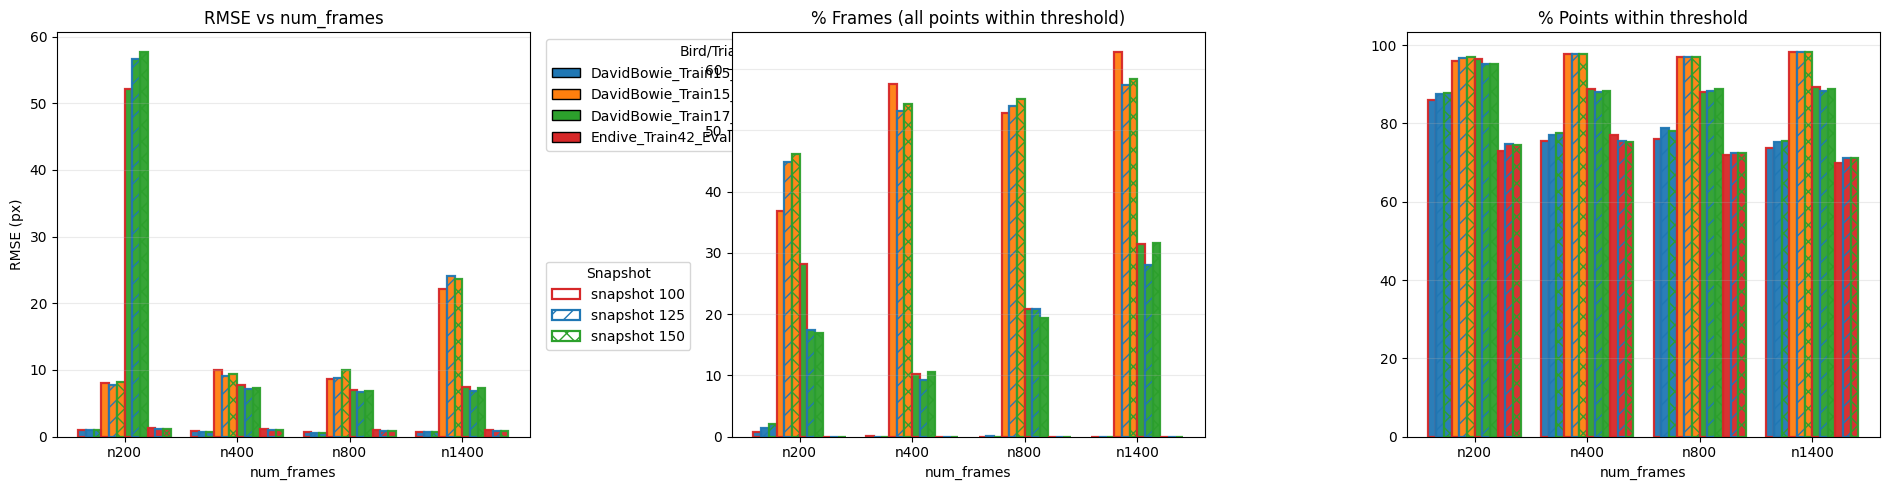

Saved model comparison bar plot to C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\model_snapshot_comparison_bars.png


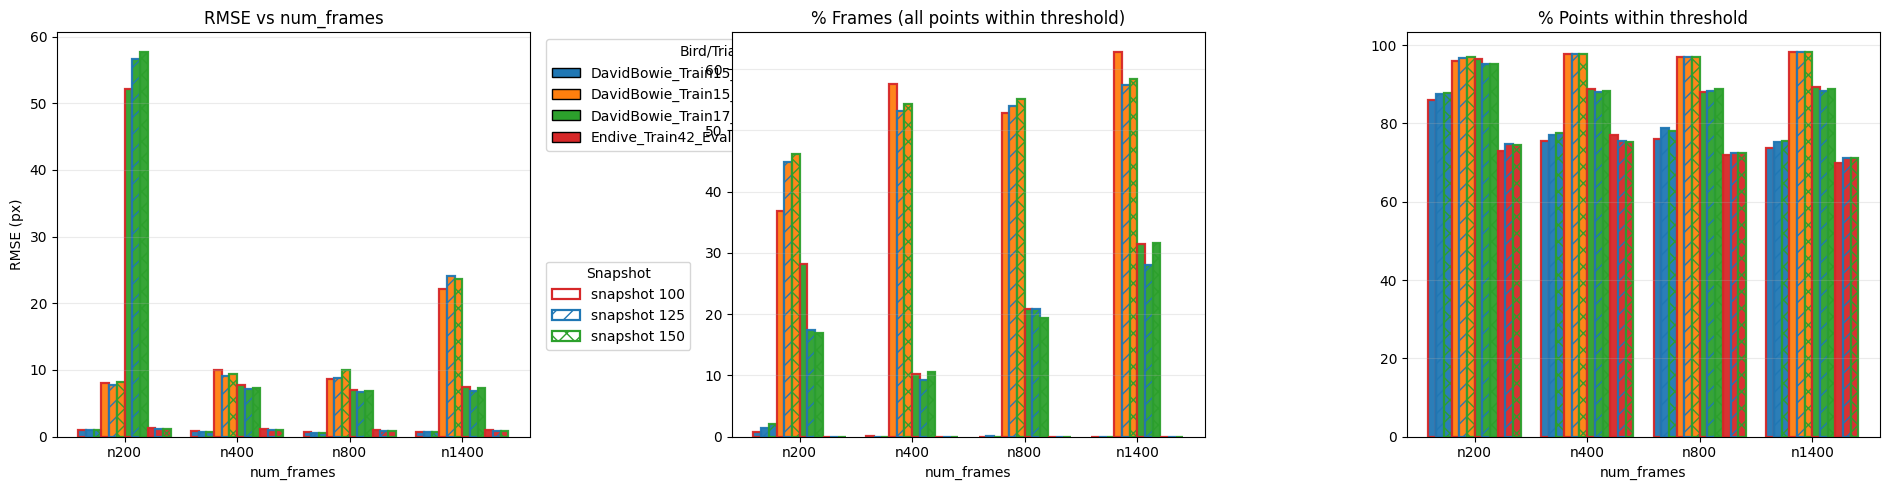

Saved RMSE vs Likelihood plot to C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\rmse_vs_likelihood.png


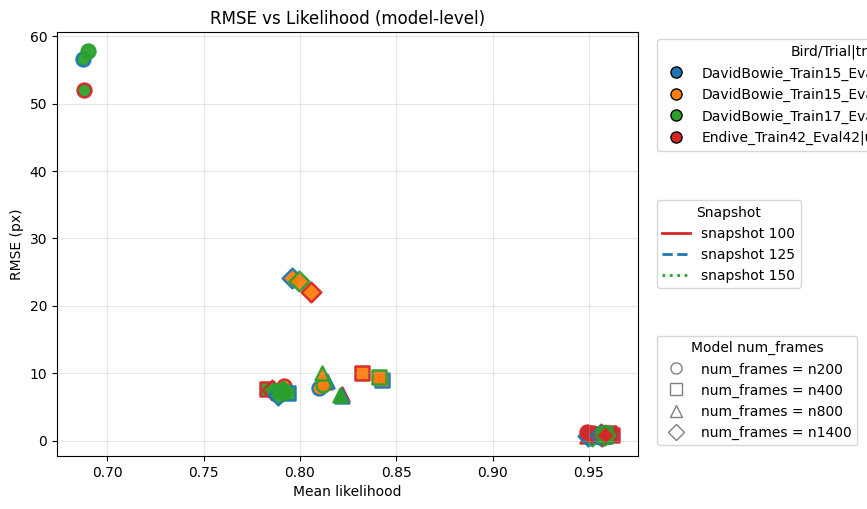

In [79]:
combined_analysis_route = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL")
# ----------------------------
# Plots: model type comparisons (snapshot-aware)
# ----------------------------
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

df = summary_df.copy()

# Normalize expected columns from your summary schema.
df["Bird_Trial"] = (
    df["bird"].astype(str)
    + "_Train"
    + df["train_trial"].astype(str)
    + "_Eval"
    + df["eval_trial"].astype(str)
)

df["num_frames"] = "n" + df["numframes"].astype(int).astype(str)
frame_order = ["n200", "n400", "n800", "n1400"]
df["num_frames"] = pd.Categorical(df["num_frames"], categories=frame_order, ordered=True)

snapshots = sorted(df["snapshot_num"].dropna().astype(int).unique().tolist())
snapshot_edge = {100: "#d62728", 125: "#1f77b4", 150: "#2ca02c"}
snapshot_hatch = {100: "", 125: "//", 150: "xx"}
snapshot_ls = {100: "-", 125: "--", 150: ":"}

# New schema-aware grouping: distinguish within-trial subset evaluations from full-truth rows.
if "truth_mode" not in df.columns:
    df["truth_mode"] = "full_truth"
df["GroupKey"] = df["Bird_Trial"] + "|" + df["truth_mode"].astype(str)
groups = sorted(df["GroupKey"].unique())
palette = sns.color_palette("tab10", n_colors=max(len(groups), 1))
group_color = {g: palette[i] for i, g in enumerate(groups)}

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

x = np.arange(len(frame_order))
n_combo = max(len(groups) * len(snapshots), 1)
bar_width = 0.82 / n_combo

# ---- grouped bars: color = GroupKey, outline/hatch = snapshot ----
for gi, g in enumerate(groups):
    for si, snap in enumerate(snapshots):
        sub = (
            df[(df["GroupKey"] == g) & (df["snapshot_num"].astype(int) == int(snap))]
            .set_index("num_frames")
            .reindex(frame_order)
        )

        combo_idx = gi * len(snapshots) + si
        offset = (combo_idx - (n_combo - 1) / 2) * bar_width

        bar_kwargs = dict(
            width=bar_width,
            color=group_color[g],
            edgecolor=snapshot_edge.get(int(snap), "black"),
            linewidth=1.6,
            hatch=snapshot_hatch.get(int(snap), ""),
            alpha=0.95,
        )

        axes[0].bar(x + offset, sub["rmse_px"], **bar_kwargs)
        axes[1].bar(x + offset, sub["percent_frames_all_points_within_threshold"], **bar_kwargs)
        axes[2].bar(x + offset, sub["percent_points_within_threshold"], **bar_kwargs)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(frame_order)
    ax.set_xlabel("num_frames")
    ax.grid(True, axis="y", alpha=0.25)

axes[0].set_title("RMSE vs num_frames")
axes[0].set_ylabel("RMSE (px)")
axes[1].set_title("% Frames (all points within threshold)")
axes[2].set_title("% Points within threshold")

group_handles = [
    Patch(facecolor=group_color[g], edgecolor="black", label=g) for g in groups
]
snap_handles = [
    Patch(
        facecolor="white",
        edgecolor=snapshot_edge.get(int(s), "black"),
        hatch=snapshot_hatch.get(int(s), ""),
        linewidth=1.6,
        label=f"snapshot {int(s)}",
    )
    for s in snapshots
]

leg1 = axes[0].legend(handles=group_handles, title="Bird/Trial|truth_mode", loc="upper left", bbox_to_anchor=(1.02, 1.0))
axes[0].add_artist(leg1)
axes[0].legend(handles=snap_handles, title="Snapshot", loc="upper left", bbox_to_anchor=(1.02, 0.45))

plt.tight_layout()
save_path = combined_analysis_route / "model_snapshot_comparison_bars.png"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved model comparison bar plot to {save_path}")
plt.show()


def _mean_likelihood_from_dlc_csvs(run_output_dir: Path) -> float:
    """Compute mean DLC likelihood from raw DLC CSVs in one run output directory.

    Returns NaN when no valid likelihood columns are found.
    """
    dlc_csvs = sorted(run_output_dir.glob("*DLC*.csv"))
    if not dlc_csvs:
        return float("nan")

    likes = []
    for p in dlc_csvs:
        try:
            wide = pd.read_csv(p, header=[0, 1, 2], index_col=0)
        except Exception:
            continue

        coord_vals = wide.columns.get_level_values(2).astype(str).str.lower()
        like_mask = coord_vals == "likelihood"
        if not like_mask.any():
            continue

        like_df = wide.loc[:, like_mask]
        vals = pd.to_numeric(like_df.to_numpy(dtype=float).ravel(), errors="coerce")
        vals = pd.Series(vals).dropna()
        if len(vals) > 0:
            likes.append(float(vals.mean()))

    if not likes:
        return float("nan")
    return float(np.mean(likes))


# Rebuild likelihood for new schema rows where evaluation stored NaN.
if "mean_likelihood" not in df.columns:
    df["mean_likelihood"] = np.nan

need_fill = df["mean_likelihood"].isna()
if need_fill.any():
    filled_vals = []
    for _, rr in df[need_fill].iterrows():
        out_dir = Path(str(rr["output_dir"]))
        filled_vals.append(_mean_likelihood_from_dlc_csvs(out_dir))
    df.loc[need_fill, "mean_likelihood"] = filled_vals

# ---- RMSE vs likelihood: color = GroupKey, edge/linestyle = snapshot, marker = num_frames ----
plt.figure(figsize=(7.5, 5.5))
marker_map = {"n200": "o", "n400": "s", "n800": "^", "n1400": "D"}

plot_df = df.dropna(subset=["mean_likelihood", "rmse_px"]).copy()
if plot_df.empty:
    print("No rows with usable mean_likelihood after rebuild from DLC CSVs.")
else:
    for g in groups:
        for snap in snapshots:
            sub = plot_df[(plot_df["GroupKey"] == g) & (plot_df["snapshot_num"].astype(int) == int(snap))].copy()
            if sub.empty:
                continue

            # sub_line = sub.sort_values("mean_likelihood")
            # plt.plot(
            #     sub_line["mean_likelihood"],
            #     sub_line["rmse_px"],
            #     linestyle=snapshot_ls.get(int(snap), "-"),
            #     color=group_color[g],
            #     alpha=0.4,
            #     linewidth=1.3,
            # )

            for _, rr in sub.iterrows():
                plt.scatter(
                    rr["mean_likelihood"],
                    rr["rmse_px"],
                    marker=marker_map.get(str(rr["num_frames"]), "o"),
                    s=100,
                    facecolors=[group_color[g]],
                    edgecolors=[snapshot_edge.get(int(snap), "black")],
                    linewidths=1.8,
                    alpha=0.95,
                )

plt.xlabel("Mean likelihood")
plt.ylabel("RMSE (px)")
plt.title("RMSE vs Likelihood (model-level)")
plt.grid(True, alpha=0.3)

observed_numframes = sorted(
    {str(v) for v in df["num_frames"].dropna().astype(str)},
    key=lambda s: int(s[1:]) if s.startswith("n") and s[1:].isdigit() else 10**9,
)

group_line_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=group_color[g],
        markeredgecolor="black",
        markersize=8,
        label=g,
    )
    for g in groups
]

snap_line_handles = [
    Line2D(
        [0], [0],
        color=snapshot_edge.get(int(s), "black"),
        linestyle=snapshot_ls.get(int(s), "-"),
        linewidth=2,
        label=f"snapshot {int(s)}",
    )
    for s in snapshots
]

numframes_handles = [
    Line2D(
        [0], [0],
        marker=marker_map.get(nf, "o"),
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="gray",
        color="gray",
        markersize=8,
        label=f"num_frames = {nf}",
    )
    for nf in observed_numframes
]

ax = plt.gca()
legend1 = ax.legend(
    handles=group_line_handles,
    title="Bird/Trial|truth_mode",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True,
)
ax.add_artist(legend1)

legend2 = ax.legend(
    handles=snap_line_handles,
    title="Snapshot",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.62),
    frameon=True,
)
ax.add_artist(legend2)

ax.legend(
    handles=numframes_handles,
    title="Model num_frames",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.30),
    frameon=True,
)

save_path = combined_analysis_route / "rmse_vs_likelihood.png"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved RMSE vs Likelihood plot to {save_path}")
plt.show()

In [80]:
# ----------------------------
# Exports
# ----------------------------

exports_root = TESTING_ROOT / "DeepLabCut2" / "DB_END_COMBINED_EVAL"
exports_root.mkdir(parents=True, exist_ok=True)

run_manifest_csv = exports_root / "subepochs_run_manifest.csv"
summary_csv = exports_root / "subepochs_summary.csv"
errors_csv = exports_root / "subepochs_errors.csv"

if 'run_results_df' in globals() and not run_results_df.empty:
    run_results_df.to_csv(run_manifest_csv, index=False)
    print(f"Wrote run manifest: {run_manifest_csv}")

if 'summary_df' in globals() and not summary_df.empty:
    summary_df.to_csv(summary_csv, index=False)
    print(f"Wrote summary: {summary_csv}")

if 'errors_df' in globals() and not errors_df.empty:
    errors_df.to_csv(errors_csv, index=False)
    print(f"Wrote errors: {errors_csv}")

Wrote run manifest: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\subepochs_run_manifest.csv
Wrote summary: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\subepochs_summary.csv
Wrote errors: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\subepochs_errors.csv


# --------------------------------------------------------- 

# Comparison with full training

In [93]:
combined_errors_df = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\combined_errors.csv")
combined_summary_df = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\combined_summary.csv")


In [96]:
# # replace all instances of 32 in train_trial, eval_trial and pair with 42
# def replace_32_with_42(s):
#     if isinstance(s, str):
#         return s.replace("32", "42")
#     if isinstance(s, int) and s == 32:
#         return 42
#     return s
# combined_errors_df["train_trial"] = combined_errors_df["train_trial"].apply(replace_32_with_42)
# combined_errors_df["eval_trial"] = combined_errors_df["eval_trial"].apply(replace_32_with_42)
# combined_errors_df["pair"] = combined_errors_df["pair"].apply(replace_32_with_42)
# combined_summary_df["train_trial"] = combined_summary_df["train_trial"].apply(replace_32_with_42)
# combined_summary_df["eval_trial"] = combined_summary_df["eval_trial"].apply(replace_32_with_42)
# combined_summary_df["pair"] = combined_summary_df["pair"].apply(replace_32_with_42)
# combined_errors_df.to_csv(exports_root / "combined_errors.csv", index=False)
# combined_summary_df.to_csv(exports_root / "combined_summary.csv", index=False)
# print(f"Replaced 32 with 42 in combined errors and summary CSVs.")

Replaced 32 with 42 in combined errors and summary CSVs.


In [101]:
subepoch_summary_df = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\subepochs_summary.csv")
print(subepoch_summary_df.head())

# FIXME: We loose Mean Likelihood in the combined summary when we make it based on XMALAB row comparison. We can try to rebuild it from the raw DLC CSVs in each run output...

         bird  train_trial  eval_trial         pair_slug  numframes  \
0  DavidBowie           15          15  TrainT15_EvalT15        200   
1  DavidBowie           15          15  TrainT15_EvalT15        200   
2  DavidBowie           15          15  TrainT15_EvalT15        200   
3  DavidBowie           15          15  TrainT15_EvalT15        400   
4  DavidBowie           15          15  TrainT15_EvalT15        400   

   snapshot_num model_dir                                         output_dir  \
0           100  n200_T15  c:\Users\Salle-Cineradio\Documents\MachineLear...   
1           125  n200_T15  c:\Users\Salle-Cineradio\Documents\MachineLear...   
2           150  n200_T15  c:\Users\Salle-Cineradio\Documents\MachineLear...   
3           100  n400_T15  c:\Users\Salle-Cineradio\Documents\MachineLear...   
4           125  n400_T15  c:\Users\Salle-Cineradio\Documents\MachineLear...   

                               prediction_xmalab_csv       comparison_mode  \
0  c:\Users\Sa

In [97]:
# ----------------------------
# Comparison with full training (interactive)
# ----------------------------
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

FULL_SUMMARY_PATH = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DB_END_COMBINED_EVAL\combined_summary.csv"
)

def _first_existing_col(df: pd.DataFrame, names: list[str]) -> str | None:
    for n in names:
        if n in df.columns:
            return n
    return None

def _normalize_eval_df(df: pd.DataFrame, default_epoch: int | None = None, source_label: str = "unknown") -> pd.DataFrame:
    d = df.copy()

    # Canonical columns (best effort)
    col_bird = _first_existing_col(d, ["bird", "Bird"])
    col_tt   = _first_existing_col(d, ["train_trial", "TrainTrial", "trainTrial"])
    col_et   = _first_existing_col(d, ["eval_trial", "EvalTrial", "evalTrial"])
    col_nf   = _first_existing_col(d, ["numframes", "num_frames", "NumFrames"])
    col_bt   = _first_existing_col(d, ["Bird_Trial", "bird_trial"])
    col_ep   = _first_existing_col(d, ["train_epoch", "epoch", "epochs", "snapshot_num", "snapshot"])

    # remove spaces from bird column values
    if col_bird is not None:
        d[col_bird] = (
            d[col_bird]
            .astype(str)
            .str.strip()
            .str.replace(r"\s+", "", regex=True)
            .str.lower()
        )

    # Build/repair Bird_Trial
    if col_bt is None:
        if all(c is not None for c in [col_bird, col_tt, col_et]):
            d["Bird_Trial"] = (
                d[col_bird].astype(str)
                + "_Train"
                + pd.to_numeric(d[col_tt], errors="coerce").astype("Int64").astype(str)
                + "_Eval"
                + pd.to_numeric(d[col_et], errors="coerce").astype("Int64").astype(str)
            )
        else:
            d["Bird_Trial"] = "Unknown"
    else:
        d["Bird_Trial"] = d[col_bt].astype(str)

    # numframes to numeric
    if col_nf is not None:
        if col_nf == "num_frames":
            d["numframes"] = d[col_nf].astype(str).str.extract(r"(\d+)")[0]
        else:
            d["numframes"] = d[col_nf]
    else:
        d["numframes"] = np.nan
    d["numframes"] = pd.to_numeric(d["numframes"], errors="coerce")

    # epoch to numeric
    if col_ep is not None:
        d["train_epoch"] = pd.to_numeric(d[col_ep], errors="coerce")
    else:
        d["train_epoch"] = np.nan

    if default_epoch is not None:
        d["train_epoch"] = d["train_epoch"].fillna(default_epoch)

    d["train_epoch"] = pd.to_numeric(d["train_epoch"], errors="coerce").astype("Int64")
    d["source"] = source_label

    # Keep expected metrics if present
    for m in [
        "rmse_px",
        "percent_frames_all_points_within_threshold",
        "percent_points_within_threshold",
        "mean_likelihood",
    ]:
        if m not in d.columns:
            d[m] = np.nan

    keep = [
        "Bird_Trial",
        "numframes",
        "train_epoch",
        "source",
        "rmse_px",
        "percent_frames_all_points_within_threshold",
        "percent_points_within_threshold",
        "mean_likelihood",
    ]
    return d[keep].copy()

# Current notebook results (sub-200 snapshots)
if "summary_df" not in globals() or summary_df.empty:
    raise ValueError("summary_df is missing or empty. Run evaluation cells first.")

sub_df_norm = _normalize_eval_df(summary_df, default_epoch=None, source_label="subepoch")

# Full training (200 epochs)
if not FULL_SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Missing file: {FULL_SUMMARY_PATH}")
full_raw = pd.read_csv(FULL_SUMMARY_PATH)
full_df_norm = _normalize_eval_df(full_raw, default_epoch=200, source_label="full")

compare_df = pd.concat([sub_df_norm, full_df_norm], ignore_index=True)
compare_df = compare_df.dropna(subset=["Bird_Trial", "numframes", "train_epoch"])
compare_df["numframes"] = compare_df["numframes"].astype(int)
compare_df["train_epoch"] = compare_df["train_epoch"].astype(int)

# Widgets
epoch_options = sorted(compare_df["train_epoch"].dropna().unique().tolist())
bird_options = sorted(compare_df["Bird_Trial"].dropna().unique().tolist())

epoch_w = widgets.SelectMultiple(
    options=epoch_options,
    value=tuple(epoch_options),
    description="Epochs",
    layout=widgets.Layout(width="260px", height="170px"),
)
bird_w = widgets.SelectMultiple(
    options=bird_options,
    value=tuple(bird_options),
    description="Bird_Trial",
    layout=widgets.Layout(width="420px", height="170px"),
)


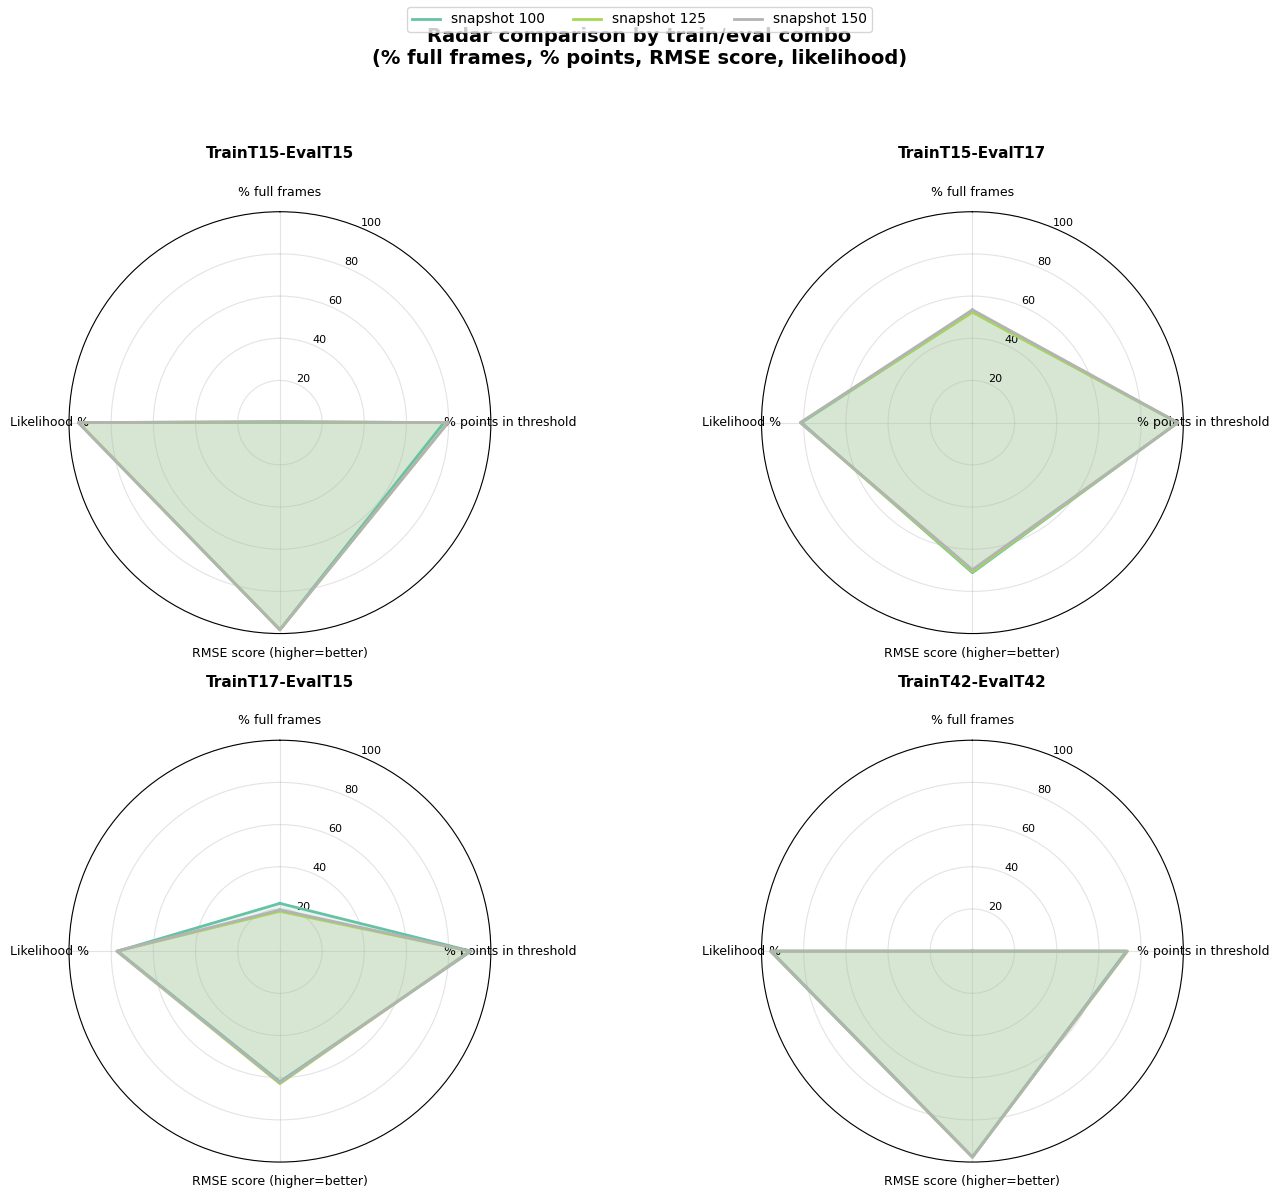

Likelihood available for 48/48 rows after backfill.


In [103]:
# ...existing code...
import ipywidgets as widgets
from IPython.display import display

def _plot_compare(selected_epochs, selected_birds, plot_mode):
    sdf = compare_df[
        compare_df["train_epoch"].isin(list(selected_epochs))
        & compare_df["Bird_Trial"].isin(list(selected_birds))
    ].copy()

    if sdf.empty:
        print("No rows match current filters.")
        return

    metric_map = {
        "RMSE (px)": "rmse_px",
        "% Frames within threshold": "percent_frames_all_points_within_threshold",
        "% Points within threshold": "percent_points_within_threshold",
    }

    # ---- Single line-plot modes ----
    if plot_mode in metric_map:
        mcol = metric_map[plot_mode]
        subm = sdf.dropna(subset=[mcol, "numframes"])
        fig, ax = plt.subplots(1, 1, figsize=(8.5, 5))

        if subm.empty:
            ax.set_title(f"{plot_mode} (no data)")
            ax.grid(True, alpha=0.3)
        else:
            sns.lineplot(
                data=subm,
                x="numframes",
                y=mcol,
                hue="Bird_Trial",
                style="train_epoch",
                markers=True,
                dashes=True,
                estimator="mean",
                errorbar=None,
                ax=ax,
            )
            ax.set_title(plot_mode)
            ax.set_xlabel("numframes")
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        return

    # ---- Single scatter mode ----
    if plot_mode == "RMSE vs Likelihood":
        sc = sdf.dropna(subset=["mean_likelihood", "rmse_px"])
        fig, ax = plt.subplots(1, 1, figsize=(8.5, 5))

        if sc.empty:
            ax.set_title("RMSE vs Likelihood (no data)")
            ax.grid(True, alpha=0.3)
        else:
            sns.scatterplot(
                data=sc,
                x="mean_likelihood",
                y="rmse_px",
                hue="Bird_Trial",
                style="train_epoch",
                size="numframes",
                sizes=(50, 180),
                alpha=0.9,
                ax=ax,
            )
            ax.set_title("RMSE vs Likelihood (model-level)")
            ax.set_xlabel("Mean likelihood")
            ax.set_ylabel("RMSE (px)")
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        return

   

# widgets
epoch_options = sorted(compare_df["train_epoch"].dropna().unique().tolist())
bird_options = sorted(compare_df["Bird_Trial"].dropna().unique().tolist())

epoch_w = widgets.SelectMultiple(
    options=epoch_options,
    value=tuple(epoch_options),
    description="Epochs",
    layout=widgets.Layout(width="260px", height="170px"),
)

bird_w = widgets.SelectMultiple(
    options=bird_options,
    value=tuple(bird_options),
    description="Bird_Trial",
    layout=widgets.Layout(width="420px", height="170px"),
)

plot_w = widgets.Dropdown(
    options=[
        "RMSE (px)",
        "% Frames within threshold",
        "% Points within threshold",
        "RMSE vs Likelihood",
        "All (4 panels)",
    ],
    value="RMSE (px)",
    description="Plot",
    layout=widgets.Layout(width="320px"),
)

ui = widgets.VBox([widgets.HBox([epoch_w, bird_w]), plot_w])
out = widgets.interactive_output(
    _plot_compare,
    {"selected_epochs": epoch_w, "selected_birds": bird_w, "plot_mode": plot_w},
)
display(ui, out)
# ...existing code...

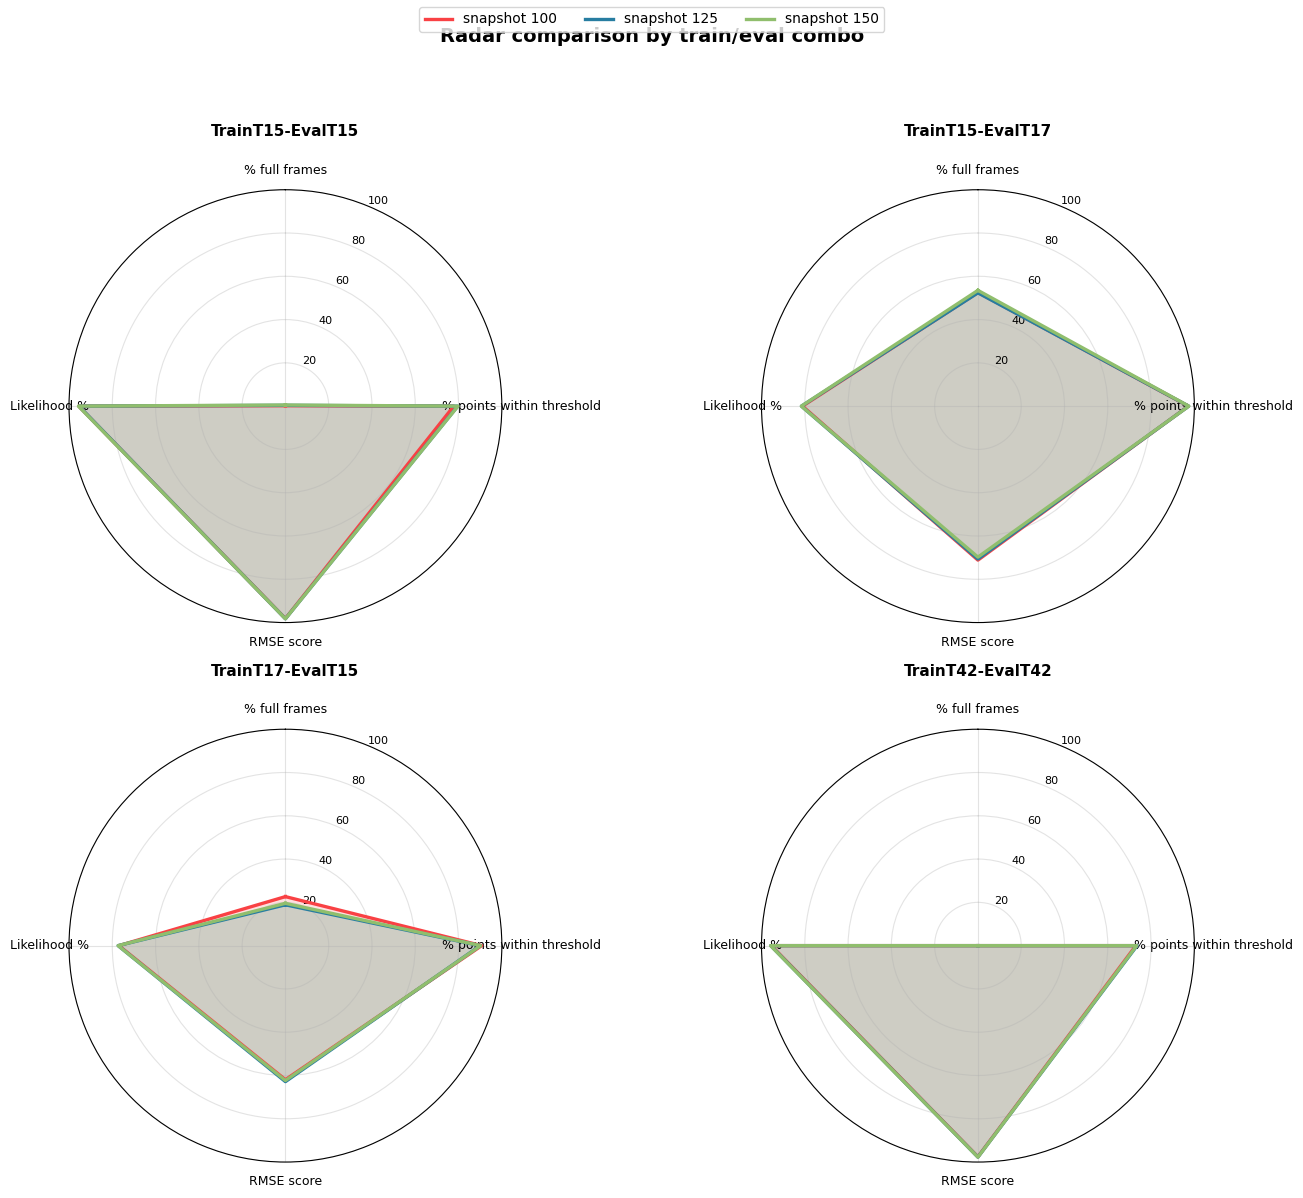

Likelihood available for 48/48 rows after backfill.


In [104]:
# Radius plot (radar): 2x2 train/eval combos, snapshot-colored traces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if "summary_df" not in globals() or summary_df.empty:
    raise ValueError("summary_df is missing or empty. Run the evaluation cell first.")


def _mean_likelihood_from_dlc_csvs(run_output_dir: Path) -> float:
    dlc_csvs = sorted(run_output_dir.glob("*DLC*.csv"))
    if not dlc_csvs:
        return float("nan")

    likes = []
    for p in dlc_csvs:
        try:
            wide = pd.read_csv(p, header=[0, 1, 2], index_col=0)
        except Exception:
            continue

        coord_vals = wide.columns.get_level_values(2).astype(str).str.lower()
        like_mask = coord_vals == "likelihood"
        if not like_mask.any():
            continue

        vals = pd.to_numeric(wide.loc[:, like_mask].to_numpy(dtype=float).ravel(), errors="coerce")
        vals = pd.Series(vals).dropna()
        if not vals.empty:
            likes.append(float(vals.mean()))

    return float(np.mean(likes)) if likes else float("nan")


def _prepare_radar_df(src: pd.DataFrame) -> pd.DataFrame:
    d = src.copy()

    required = [
        "train_trial", "eval_trial", "snapshot_num", "rmse_px",
        "percent_frames_all_points_within_threshold", "percent_points_within_threshold",
    ]
    missing = [c for c in required if c not in d.columns]
    if missing:
        raise ValueError(f"summary_df missing required columns: {missing}")

    if "mean_likelihood" not in d.columns:
        d["mean_likelihood"] = np.nan

    if "output_dir" in d.columns:
        need_fill = d["mean_likelihood"].isna()
        if need_fill.any():
            cache = {}
            filled_vals = []
            for _, rr in d[need_fill].iterrows():
                out_dir = Path(str(rr["output_dir"]))
                key = str(out_dir)
                if key not in cache:
                    cache[key] = _mean_likelihood_from_dlc_csvs(out_dir)
                filled_vals.append(cache[key])
            d.loc[need_fill, "mean_likelihood"] = filled_vals

    d["Combo"] = "TrainT" + d["train_trial"].astype(int).astype(str) + "-EvalT" + d["eval_trial"].astype(int).astype(str)

    d["metric_frames_pct"] = pd.to_numeric(
        d["percent_frames_all_points_within_threshold"], errors="coerce"
    ).clip(0, 100)
    d["metric_points_pct"] = pd.to_numeric(
        d["percent_points_within_threshold"], errors="coerce"
    ).clip(0, 100)

    rmse = pd.to_numeric(d["rmse_px"], errors="coerce")
    rmse_finite = rmse.replace([np.inf, -np.inf], np.nan).dropna()
    if rmse_finite.empty:
        d["metric_rmse_score"] = np.nan
    else:
        rmse_cap = float(np.percentile(rmse_finite, 95)) if len(rmse_finite) > 3 else float(rmse_finite.max())
        rmse_cap = max(rmse_cap, 1e-9)
        d["metric_rmse_score"] = (1.0 - rmse.clip(0, rmse_cap) / rmse_cap) * 100.0

    like = pd.to_numeric(d["mean_likelihood"], errors="coerce")
    d["metric_likelihood_pct"] = (like * 100.0).clip(0, 100)

    return d


radar_df = _prepare_radar_df(summary_df)

combo_order = (
    radar_df.groupby("Combo", as_index=False)
    .size()
    .sort_values(["size", "Combo"], ascending=[False, True])["Combo"]
    .tolist()
)[:4]

if len(combo_order) < 4:
    raise ValueError(f"Need at least 4 train/eval combos for 2x2 radar; found {len(combo_order)}")

plot_df = radar_df[radar_df["Combo"].isin(combo_order)].copy()
agg_cols = [
    "metric_frames_pct",
    "metric_points_pct",
    "metric_rmse_score",
    "metric_likelihood_pct",
]
agg = (
    plot_df.groupby(["Combo", "snapshot_num"], as_index=False)[agg_cols]
    .mean()
    .sort_values(["Combo", "snapshot_num"])
)

metrics = [
    "metric_frames_pct",
    "metric_points_pct",
    "metric_rmse_score",
    "metric_likelihood_pct",
]
labels = [
    "% full frames",
    "% points within threshold",
    "RMSE score",
    "Likelihood %",
]
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles = angles + angles[:1]

snapshots = sorted(agg["snapshot_num"].dropna().astype(int).unique().tolist())
palette = ["#f94144", "#277da1", "#90be6d", "#f8961e", "#577590", "#f9844a"]
snap_color = {snap: palette[i % len(palette)] for i, snap in enumerate(snapshots)}

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw={"projection": "polar"})
axes = axes.ravel()

for i, combo in enumerate(combo_order):
    ax = axes[i]
    sub = agg[agg["Combo"] == combo].copy()

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=8)
    ax.grid(alpha=0.35)

    for snap in snapshots:
        row = sub[sub["snapshot_num"].astype(int) == int(snap)]
        if row.empty:
            continue
        vals = row.iloc[0][metrics].to_numpy(dtype=float)
        vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        vals = np.clip(vals, 0, 100)
        vals = vals.tolist() + [vals[0]]

        ax.plot(angles, vals, color=snap_color[snap], linewidth=2.4, label=f"snapshot {snap}")
        ax.fill(angles, vals, color=snap_color[snap], alpha=0.16)

    ax.set_title(combo, pad=20, fontsize=11, fontweight="bold")

handles = [
    plt.Line2D([0], [0], color=snap_color[s], lw=2.4, label=f"snapshot {s}") for s in snapshots
]
fig.legend(handles=handles, loc="upper center", ncol=max(1, len(handles)), frameon=True)
fig.suptitle("Radar comparison by train/eval combo", y=0.98, fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

n_like = int(radar_df["metric_likelihood_pct"].notna().sum())
print(f"Likelihood available for {n_like}/{len(radar_df)} rows after backfill.")

In [244]:
df_plot = compare_df.copy()
df_plot['Bird_Trial'].unique()

array(['davidbowie_Train15_Eval15', 'davidbowie_Train15_Eval17',
       'davidbowie_Train17_Eval15', 'endive_Train32_Eval32'], dtype=object)

In [99]:
# ...existing code...
import datetime

import ipywidgets as widgets
from IPython.display import display
from matplotlib.lines import Line2D

# Uses compare_df (already built from subepoch + full)
df_plot = compare_df.copy()
df_plot["num_frames"] = "n" + df_plot["numframes"].astype(int).astype(str)

marker_map = {"n200": "o", "n400": "s", "n800": "^", "n1400": "D"}

groups = sorted(df_plot["Bird_Trial"].dropna().unique().tolist())
palette = sns.color_palette("tab10", n_colors=max(len(groups), 1))
group_color = {g: palette[i] for i, g in enumerate(groups)}

epoch_options = sorted(df_plot["train_epoch"].dropna().astype(int).unique().tolist())
bird_options = sorted(df_plot["Bird_Trial"].dropna().unique().tolist())

# epoch border colors (train_epoch)
epoch_values_all = sorted(df_plot["train_epoch"].dropna().astype(int).unique().tolist())
epoch_edge = {100: "#d62728", 125: "#1f77b4", 150: "#2ca02c", 200: "#9467bd"}
for i, ep in enumerate(epoch_values_all):
    if ep not in epoch_edge:
        epoch_edge[ep] = sns.color_palette("tab10", n_colors=max(len(epoch_values_all), 1))[i]

default_save_dir = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL"

def _plot_rmse_likelihood_widget(selected_epochs, selected_birds, save_plot, save_dir, save_name):
    sdf = df_plot[
        df_plot["train_epoch"].isin(list(selected_epochs))
        & df_plot["Bird_Trial"].isin(list(selected_birds))
    ].copy()

    sdf = sdf.dropna(subset=["mean_likelihood", "rmse_px", "num_frames", "train_epoch"])
    if sdf.empty:
        print("No rows match current filters.")
        return

    plt.figure(figsize=(10, 7))

    for g in sorted(sdf["Bird_Trial"].unique()):
        for ep in sorted(sdf["train_epoch"].astype(int).unique()):
            sub = sdf[(sdf["Bird_Trial"] == g) & (sdf["train_epoch"].astype(int) == int(ep))].copy()
            if sub.empty:
                continue

            for _, r in sub.iterrows():
                point_size = 250 if int(r["train_epoch"]) == 200 else 90
                alpha = 0.95 if int(r["train_epoch"]) == 200 else 0.75
                plt.scatter(
                    r["mean_likelihood"],
                    r["rmse_px"],
                    marker=marker_map.get(str(r["num_frames"]), "o"),
                    s=point_size,
                    facecolors=[group_color[g]],
                    edgecolors=[epoch_edge.get(int(r["train_epoch"]), "black")],  # <-- epoch border color
                    
                    linewidths=2.2,
                    alpha=alpha,
                )

    plt.xlabel("Mean likelihood")
    plt.ylabel("RMSE (px)")
    plt.title("RMSE vs Likelihood (full epoch=200 shown larger)")
    plt.grid(True, alpha=0.3)

    # legends
    observed_numframes = sorted(
        {str(v) for v in sdf["num_frames"].dropna().astype(str)},
        key=lambda s: int(s[1:]) if s.startswith("n") and s[1:].isdigit() else 10**9,
    )

    bird_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor=group_color[g], markeredgecolor="black",
               markersize=8, label=g)
        for g in sorted(sdf["Bird_Trial"].unique())
    ]

    epoch_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor="white", markeredgecolor=epoch_edge.get(int(ep), "black"),
               markeredgewidth=1.8, markersize=8, label=f"epoch {int(ep)}")
        for ep in sorted(sdf["train_epoch"].astype(int).unique())
    ]
    numframes_handles = [
        Line2D([0], [0], marker=marker_map.get(nf, "o"), linestyle="None",
               markerfacecolor="white", markeredgecolor="gray",
               color="gray", markersize=8, label=f"num_frames = {nf}")
        for nf in observed_numframes
    ]

    size_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor="white", markeredgecolor="black",
               markersize=7, label="epochs != 200"),
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor="white", markeredgecolor="black",
               markersize=11, label="epoch = 200 (full)"),
    ]

    ax = plt.gca()
    leg1 = ax.legend(handles=bird_handles, title="Bird / Trial",
                     loc="upper left", bbox_to_anchor=(.7, 1.0), frameon=True)
    ax.add_artist(leg1)
    
    leg2 = ax.legend(handles=epoch_handles, title="Train epoch (border)",
                     loc="upper left", bbox_to_anchor=(.7, 0.8), frameon=True)
    ax.add_artist(leg2)

    ax.legend(handles=numframes_handles, title="Model num_frames",
                     loc="upper left", bbox_to_anchor=(.7, 0.6), frameon=True)
    # ax.add_artist(leg3)

    # ax.legend(handles=size_handles, title="Point size",
    #           loc="upper left", bbox_to_anchor=(1.02, 0.30), frameon=True)

    plt.tight_layout()

    if save_plot:
        out_dir = Path(save_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        stem = save_name.strip() if str(save_name).strip() else f"rmse_vs_likelihood_widget_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        out_path = out_dir / f"{stem}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {out_path}")

    
    plt.show()

epoch_w2 = widgets.SelectMultiple(
    options=epoch_options,
    value=tuple(epoch_options),
    description="Epochs",
    layout=widgets.Layout(width="260px", height="170px"),
)

bird_w2 = widgets.SelectMultiple(
    options=bird_options,
    value=tuple(bird_options),
    description="Bird_Trial",
    layout=widgets.Layout(width="420px", height="170px"),
)

save_w = widgets.Checkbox(value=False, description="Save plot")
save_dir_w = widgets.Text(value=default_save_dir, description="Save dir", layout=widgets.Layout(width="700px"))
save_name_w = widgets.Text(value="rmse_vs_likelihood_widget", description="File name", layout=widgets.Layout(width="500px"))

ui2 = widgets.VBox([
    widgets.HBox([epoch_w2, bird_w2]),
    widgets.HBox([save_w, save_name_w]),
    save_dir_w,
])

out2 = widgets.interactive_output(
    _plot_rmse_likelihood_widget,
    {
        "selected_epochs": epoch_w2,
        "selected_birds": bird_w2,
        "save_plot": save_w,
        "save_dir": save_dir_w,
        "save_name": save_name_w,
    },
)
display(ui2, out2)

# ...existing code...

Output()

In [100]:
# ...existing code...
import datetime
import ipywidgets as widgets
from IPython.display import display
from matplotlib.lines import Line2D

df_plot = compare_df.copy()
df_plot["numframes"] = pd.to_numeric(df_plot["numframes"], errors="coerce").astype("Int64")
df_plot["num_frames"] = "n" + df_plot["numframes"].astype(str)

marker_map = {"n200": "o", "n400": "s", "n800": "^", "n1400": "D"}

groups = sorted(df_plot["Bird_Trial"].dropna().unique().tolist())
palette = sns.color_palette("tab10", n_colors=max(len(groups), 1))
group_color = {g: palette[i] for i, g in enumerate(groups)}

epoch_options = sorted(df_plot["train_epoch"].dropna().astype(int).unique().tolist())
bird_options = sorted(df_plot["Bird_Trial"].dropna().unique().tolist())
numframes_options = sorted(df_plot["numframes"].dropna().astype(int).unique().tolist())  # ints

epoch_values_all = sorted(df_plot["train_epoch"].dropna().astype(int).unique().tolist())
epoch_edge = {100: "#d62728", 125: "#1f77b4", 150: "#2ca02c", 200: "#9467bd"}
for i, ep in enumerate(epoch_values_all):
    if ep not in epoch_edge:
        epoch_edge[ep] = sns.color_palette("tab10", n_colors=max(len(epoch_values_all), 1))[i]

default_save_dir = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL"

def _plot_rmse_likelihood_widget(selected_epochs, selected_birds, selected_nframes, save_plot, save_dir, save_name):
    sdf = df_plot[
        df_plot["train_epoch"].isin(list(selected_epochs))
        & df_plot["Bird_Trial"].isin(list(selected_birds))
        & df_plot["numframes"].astype(int).isin(list(selected_nframes))   # now same type
    ].copy()

    sdf = sdf.dropna(subset=["mean_likelihood", "rmse_px", "num_frames", "train_epoch"])
    if sdf.empty:
        print("No rows match current filters.")
        return

    plt.figure(figsize=(11, 7))

    for g in sorted(sdf["Bird_Trial"].unique()):
        for ep in sorted(sdf["train_epoch"].astype(int).unique()):
            sub = sdf[(sdf["Bird_Trial"] == g) & (sdf["train_epoch"].astype(int) == int(ep))].copy()
            if sub.empty:
                continue

            for _, r in sub.iterrows():
                point_size = 250 if int(r["train_epoch"]) == 200 else 90
                alpha = 0.95 if int(r["train_epoch"]) == 200 else 0.75
                plt.scatter(
                    r["mean_likelihood"],
                    r["rmse_px"],
                    marker=marker_map.get(str(r["num_frames"]), "o"),
                    s=point_size,
                    facecolors=[group_color[g]],
                    edgecolors=[epoch_edge.get(int(r["train_epoch"]), "black")],
                    linewidths=2.2,
                    alpha=alpha,
                )

    plt.xlabel("Mean likelihood")
    plt.ylabel("RMSE (px)")
    plt.title("RMSE vs Likelihood (full epoch=200 shown larger)")
    plt.grid(True, alpha=0.3)

    observed_numframes = sorted(
        {str(v) for v in sdf["num_frames"].dropna().astype(str)},
        key=lambda s: int(s[1:]) if s.startswith("n") and s[1:].isdigit() else 10**9,
    )

    bird_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor=group_color[g], markeredgecolor="black",
               markersize=8, label=g)
        for g in sorted(sdf["Bird_Trial"].unique())
    ]

    epoch_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor="white", markeredgecolor=epoch_edge.get(int(ep), "black"),
               markeredgewidth=1.8, markersize=8, label=f"epoch {int(ep)}")
        for ep in sorted(sdf["train_epoch"].astype(int).unique())
    ]

    numframes_handles = [
        Line2D([0], [0], marker=marker_map.get(nf, "o"), linestyle="None",
               markerfacecolor="white", markeredgecolor="gray",
               color="gray", markersize=8, label=f"num_frames = {nf}")
        for nf in observed_numframes
    ]
    ax = plt.gca()
    leg1 = ax.legend(handles=bird_handles, title="Bird / Trial",
                     loc="upper left", bbox_to_anchor=(.7, 1.0), frameon=True)
    ax.add_artist(leg1)
    
    leg2 = ax.legend(handles=epoch_handles, title="Train epoch (border)",
                     loc="upper left", bbox_to_anchor=(.7, 0.8), frameon=True)
    ax.add_artist(leg2)

    ax.legend(handles=numframes_handles, title="Model num_frames",
                     loc="upper left", bbox_to_anchor=(.7, 0.6), frameon=True)
    fig.subplots_adjust(right=0.68)

    if save_plot:
        out_dir = Path(save_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        stem = save_name.strip() if str(save_name).strip() else f"rmse_vs_likelihood_widget_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
        out_path = out_dir / f"{stem}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()

epoch_w2 = widgets.SelectMultiple(
    options=epoch_options,
    value=tuple(epoch_options),
    description="Epochs",
    layout=widgets.Layout(width="260px", height="170px"),
)

bird_w2 = widgets.SelectMultiple(
    options=bird_options,
    value=tuple(bird_options),
    description="Bird_Trial",
    layout=widgets.Layout(width="420px", height="170px"),
)

nframes_w2 = widgets.SelectMultiple(
    options=numframes_options,                
    value=tuple(numframes_options),
    description="numframes",
    layout=widgets.Layout(width="220px", height="170px"),
)

save_w = widgets.Checkbox(value=False, description="Save plot")
save_dir_w = widgets.Text(value=default_save_dir, description="Save dir", layout=widgets.Layout(width="700px"))
save_name_w = widgets.Text(value="rmse_vs_likelihood_subepochComp", description="File name", layout=widgets.Layout(width="500px"))

ui2 = widgets.VBox([
    widgets.HBox([epoch_w2, bird_w2, nframes_w2]),
    widgets.HBox([save_w, save_name_w]),
    save_dir_w,
])

out2 = widgets.interactive_output(
    _plot_rmse_likelihood_widget,
    {
        "selected_epochs": epoch_w2,
        "selected_birds": bird_w2,
        "selected_nframes": nframes_w2,
        "save_plot": save_w,
        "save_dir": save_dir_w,
        "save_name": save_name_w,
    },
)

display(ui2, out2)
# ...existing code...

Output()